In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn import preprocessing
from sklearn.metrics import recall_score, accuracy_score, confusion_matrix, f1_score, matthews_corrcoef
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import precision_score, auc, roc_auc_score, roc_curve, precision_recall_curve, classification_report, make_scorer
import pickle
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
warnings.filterwarnings('ignore')

# New Section

In [ ]:
#displaying last 5 patient data
df = pd.read_csv('/content/drive/MyDrive/UCI_5DB_918_12/heart_statlog_cleveland_hungary_final.csv')
df1 = df.copy()
df.tail(5)

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
1185,45,1,1,110,264,0,0,132,0,1.2,2,1
1186,68,1,4,144,193,1,0,141,0,3.4,2,1
1187,57,1,4,130,131,0,0,115,1,1.2,2,1
1188,57,0,2,130,236,0,2,174,0,0.0,2,1
1189,38,1,3,138,175,0,0,173,0,0.0,1,0


# New Section

In [ ]:
df.shape
df.info()
df.describe(include='all')
df.corr()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1190 non-null   int64  
 1   sex                  1190 non-null   int64  
 2   chest pain type      1190 non-null   int64  
 3   resting bp s         1190 non-null   int64  
 4   cholesterol          1190 non-null   int64  
 5   fasting blood sugar  1190 non-null   int64  
 6   resting ecg          1190 non-null   int64  
 7   max heart rate       1190 non-null   int64  
 8   exercise angina      1190 non-null   int64  
 9   oldpeak              1190 non-null   float64
 10  ST slope             1190 non-null   int64  
 11  target               1190 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 111.7 KB


,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
age,1.000000,0.015096,0.149055,0.257692,-0.046472,0.178923,0.194595,-0.368676,0.188095,0.245093,0.237749,0.262029
sex,0.015096,1.000000,0.138405,-0.006443,-0.208441,0.110961,-0.022225,-0.181837,0.194380,0.096390,0.127913,0.311267
chest pain type,0.149055,0.138405,1.000000,0.009466,-0.109396,0.076492,0.035705,-0.337491,0.403428,0.224106,0.276949,0.460127
resting bp s,0.257692,-0.006443,0.009466,1.000000,0.099037,0.088235,0.095860,-0.101357,0.142435,0.176111,0.089384,0.121415
cholesterol,-0.046472,-0.208441,-0.109396,0.099037,1.000000,-0.239778,0.150879,0.238028,-0.033261,0.057451,-0.100053,-0.198366
fasting blood sugar,0.178923,0.110961,0.076492,0.088235,-0.239778,1.000000,0.032124,-0.118689,0.053053,0.031193,0.145902,0.216695
resting ecg,0.194595,-0.022225,0.035705,0.095860,0.150879,0.032124,1.000000,0.058812,0.037821,0.126023,0.093629,0.073059
max heart rate,-0.368676,-0.181837,-0.337491,-0.101357,0.238028,-0.118689,0.058812,1.000000,-0.377691,-0.183688,-0.350750,-0.413278
exercise angina,0.188095,0.194380,0.403428,0.142435,-0.033261,0.053053,0.037821,-0.377691,1.000000,0.370772,0.393408,0.481467
oldpeak,0.245093,0.096390,0.224106,0.176111,0.057451,0.031193,0.126023,-0.183688,0.370772,1.000000,0.524639,0.398385


Total HF = 629
Total NO HF = 561


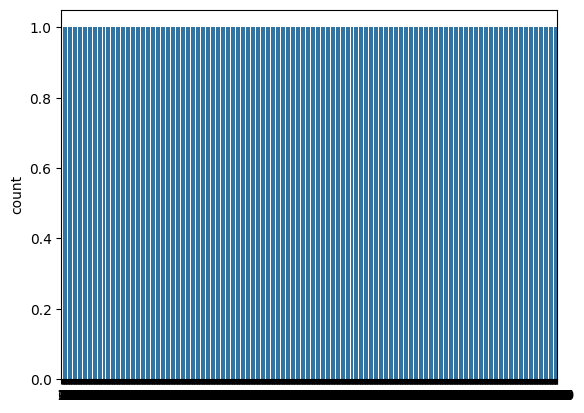

In [ ]:

HF = df[df["target"] == 1].shape[0]
Not_HF = df[df["target"] == 0].shape[0]

print(f"Total HF = {HF}")
print(f"Total NO HF = {Not_HF}")

sns.countplot(df['target'])
plt.show()

In [ ]:
df['target'].value_counts()

,count
target,
1,629
0,561


In [ ]:
df.describe()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
count,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000
mean,53.720168,0.763866,3.232773,132.153782,210.363866,0.213445,0.698319,139.732773,0.387395,0.922773,1.624370,0.528571
std,9.358203,0.424884,0.935480,18.368823,101.420489,0.409912,0.870359,25.517636,0.487360,1.086337,0.610459,0.499393
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000
25%,47.000000,1.000000,3.000000,120.000000,188.000000,0.000000,0.000000,121.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,229.000000,0.000000,0.000000,140.500000,0.000000,0.600000,2.000000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,269.750000,0.000000,2.000000,160.000000,1.000000,1.600000,2.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,1.000000


In [ ]:
df.isna().sum()

,0
age,0
sex,0
chest pain type,0
resting bp s,0
cholesterol,0
fasting blood sugar,0
resting ecg,0
max heart rate,0
exercise angina,0
oldpeak,0


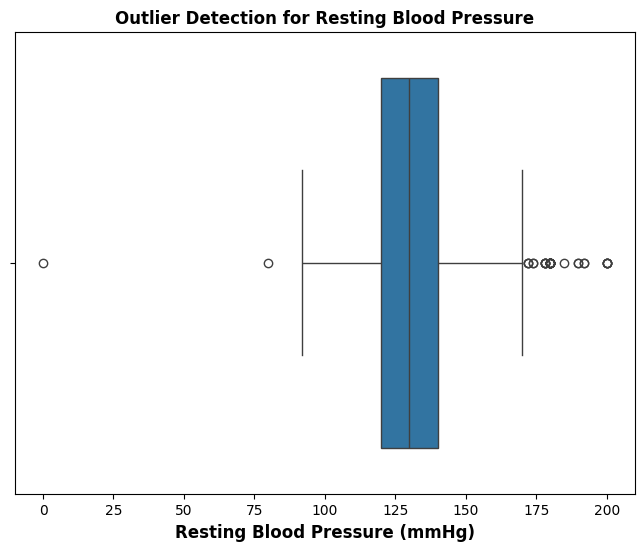

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(x=df['resting bp s'], color='#1f77b4')  # Dark blue color
plt.xlabel('Resting Blood Pressure (mmHg)', fontsize=12, fontweight='bold')
plt.title('Outlier Detection for Resting Blood Pressure', fontsize=12, fontweight='bold')
plt.show()


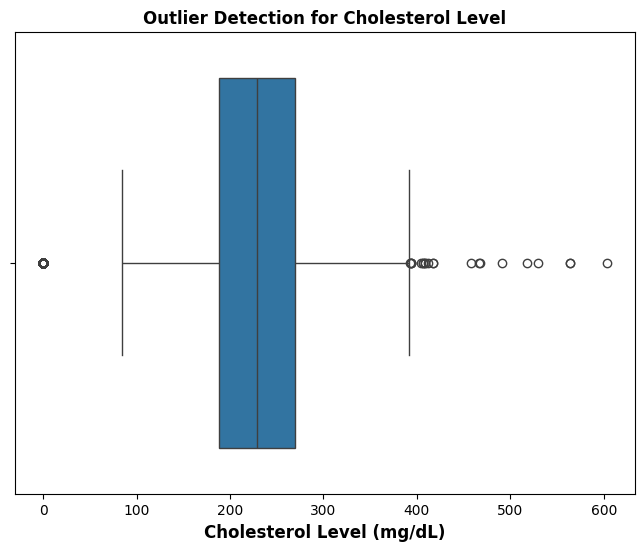

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['cholesterol'], color='#1f77b4')  # Dark blue color
plt.xlabel('Cholesterol Level (mg/dL)', fontsize=12, fontweight='bold')
plt.title('Outlier Detection for Cholesterol Level', fontsize=12, fontweight='bold')
plt.show()


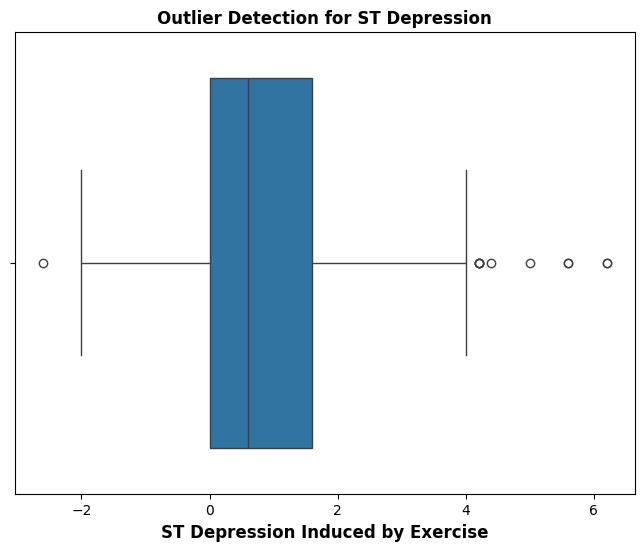

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['oldpeak'], color='#1f77b4')  # Dark blue color
plt.xlabel('ST Depression Induced by Exercise', fontsize=12, fontweight='bold')
plt.title('Outlier Detection for ST Depression', fontsize=12, fontweight='bold')
plt.show()


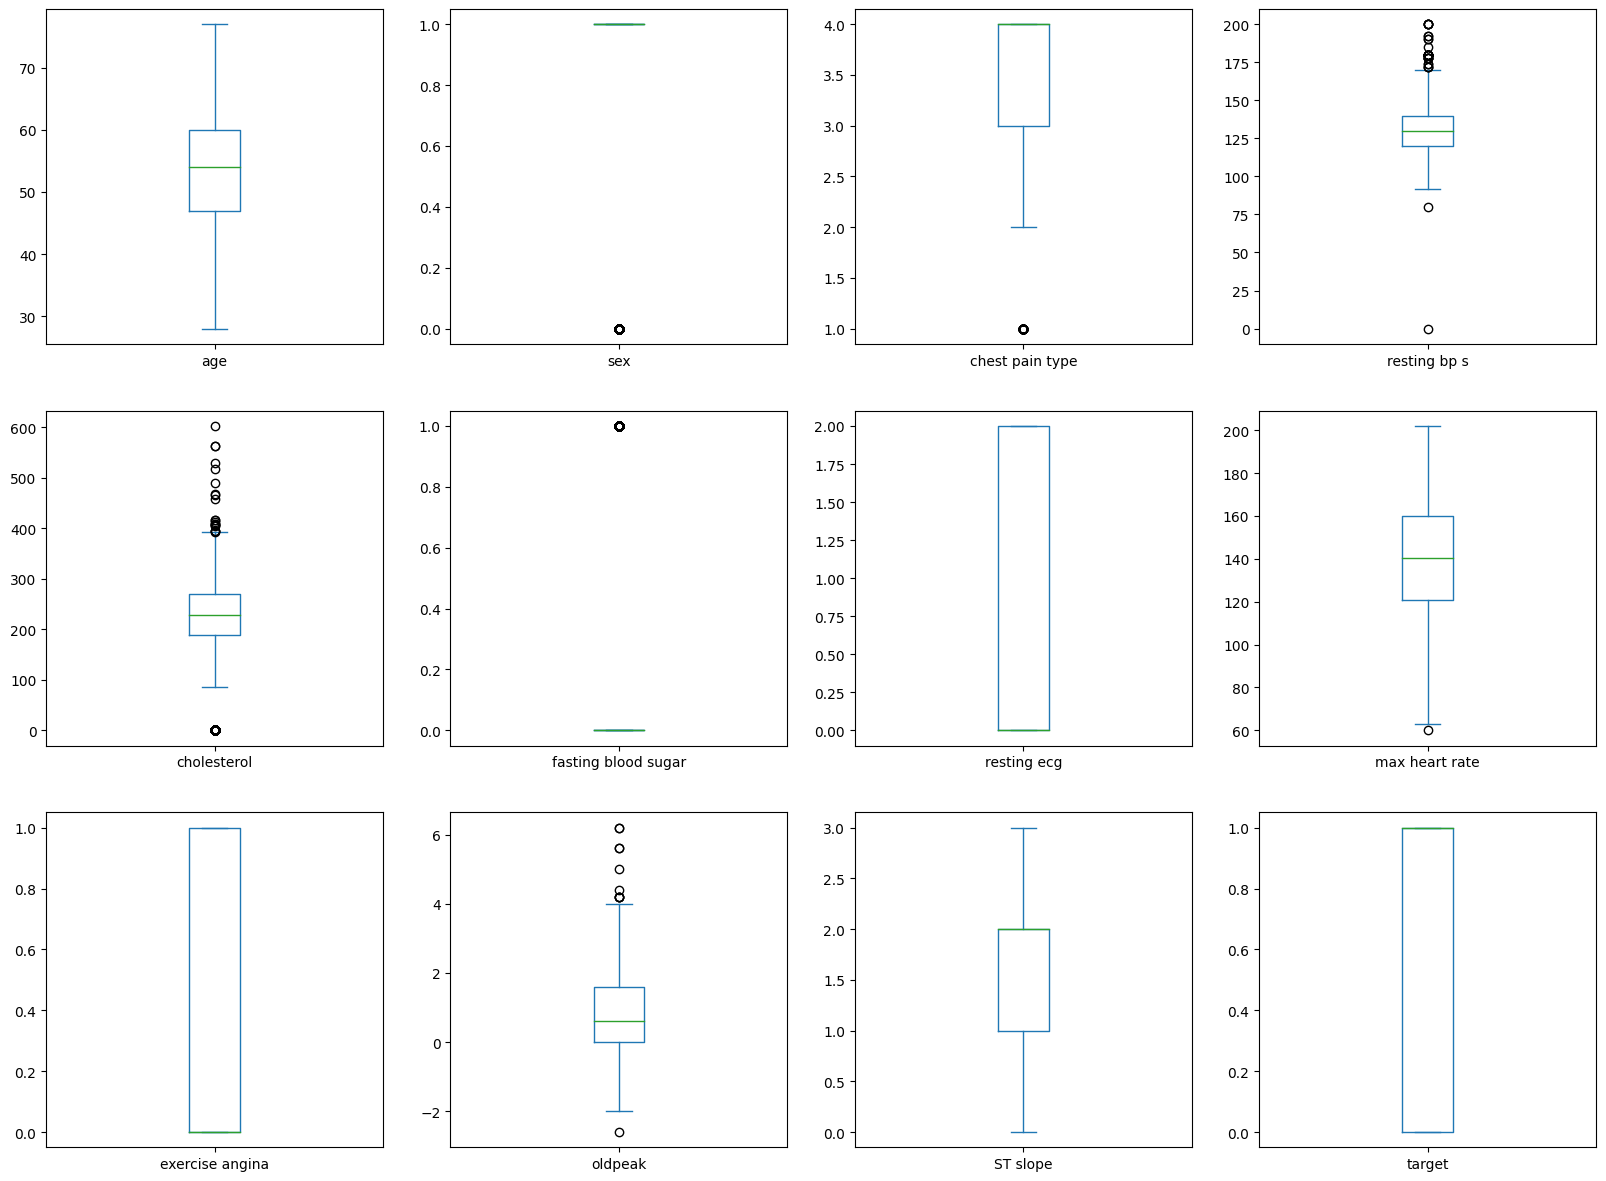

In [ ]:
#original data plot using BOX
fig = plt.figure(figsize=(20, 20))
ax = fig.gca()
df.plot(kind='box', subplots=True, layout=(4, 4), sharex=False, ax=ax)
plt.show()

In [ ]:
cols = ['resting bp s','oldpeak','cholesterol'] # one or more columns with outlier

Q1 = df[cols].quantile(0.25)
Q3 = df[cols].quantile(0.75)
IQR = Q3 - Q1
print('total outlier : \n',((df[cols] < (Q1 - 1.5 * IQR)) | (df[cols] > (Q3 + 1.5 * IQR))).sum()) # Subset the DataFrame with cols before comparison
df = df[~((df[cols] < (Q1 - 1.5 * IQR)) |(df[cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

total outlier : 
 resting bp s     37
oldpeak          11
cholesterol     193
dtype: int64


In [ ]:
upper_limit = Q1 + 1.5 * IQR
lower_limit = Q3 - 1.5 * IQR

In [ ]:
new_df = df[cols] < upper_limit
new_df.shape

(961, 3)

In [ ]:
df[cols] = np.where(df[cols] >= upper_limit,
        upper_limit,
        np.where(df[cols] <= lower_limit,
        lower_limit,
        df[cols]))

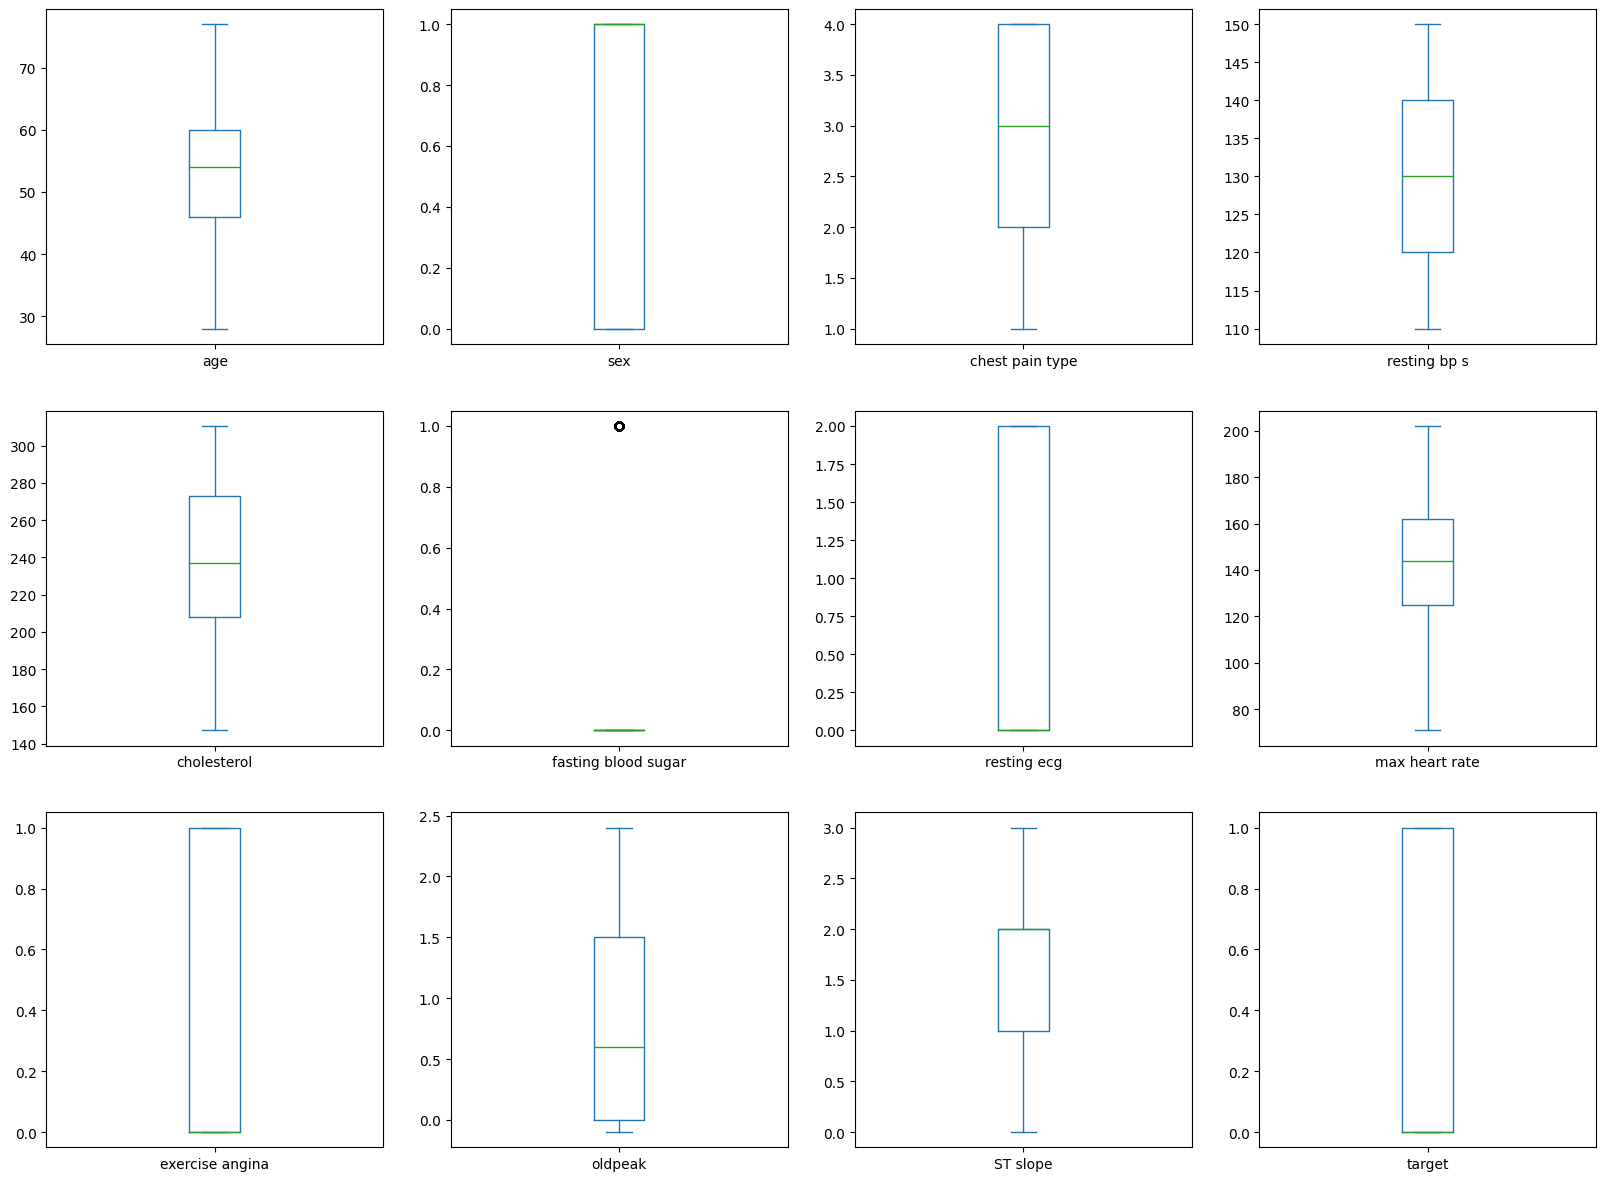

In [ ]:
fig = plt.figure(figsize=(20, 20))
ax = fig.gca()
df.plot(kind='box', subplots=True, layout=(4, 4), sharex=False, ax=ax)
plt.show()

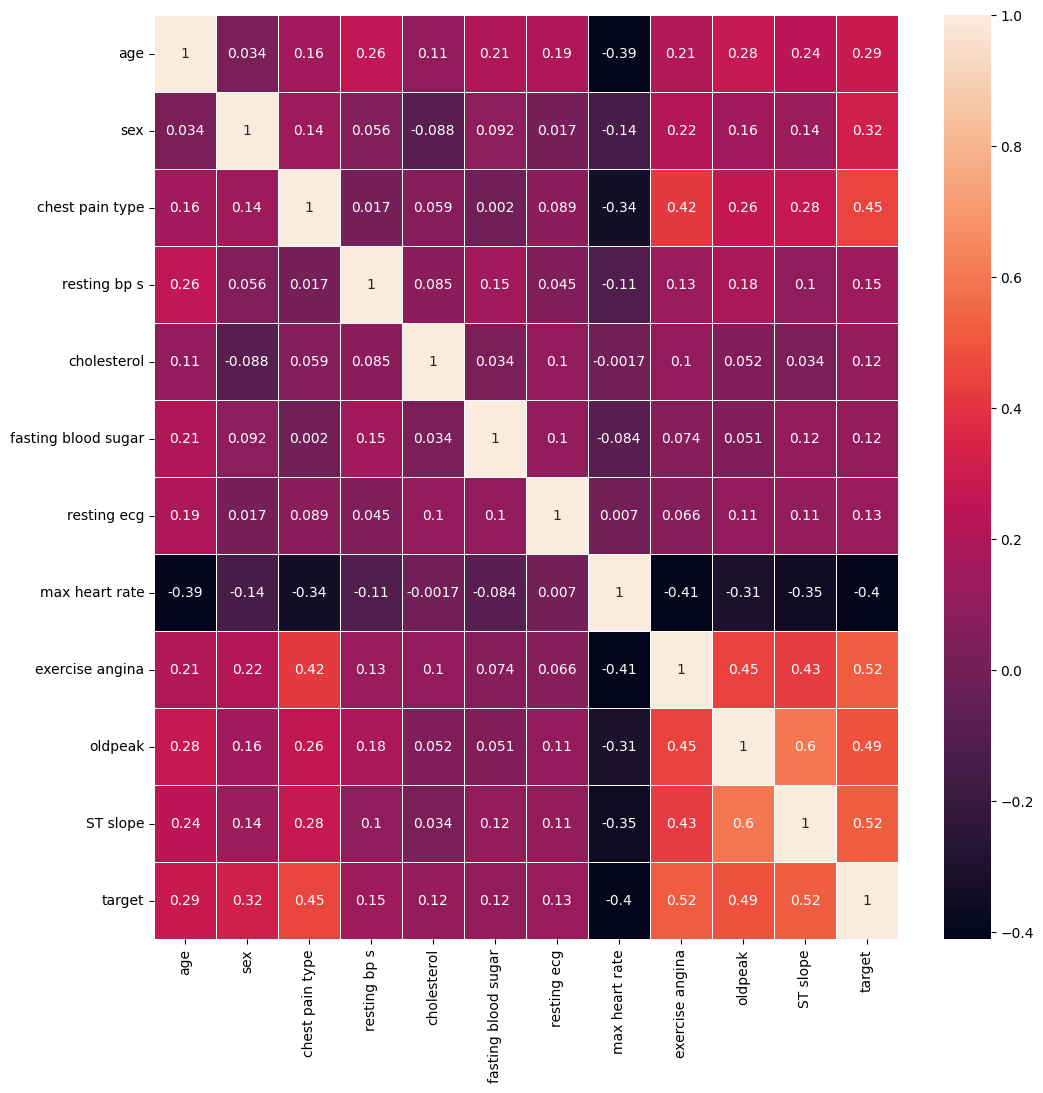

In [ ]:
#displaying correlation matrix
fig, ax = plt.subplots(figsize = (12,12))
sns.heatmap(df.corr(), annot = True, linewidths = .5, ax = ax)
plt.show()

In [ ]:
print(df.corr()["target"].sort_values(ascending=False))

target                 1.000000
ST slope               0.522354
exercise angina        0.518085
oldpeak                0.488353
chest pain type        0.450947
sex                    0.319549
age                    0.285016
resting bp s           0.147689
resting ecg            0.132532
cholesterol            0.116761
fasting blood sugar    0.116026
max heart rate        -0.402171
Name: target, dtype: float64


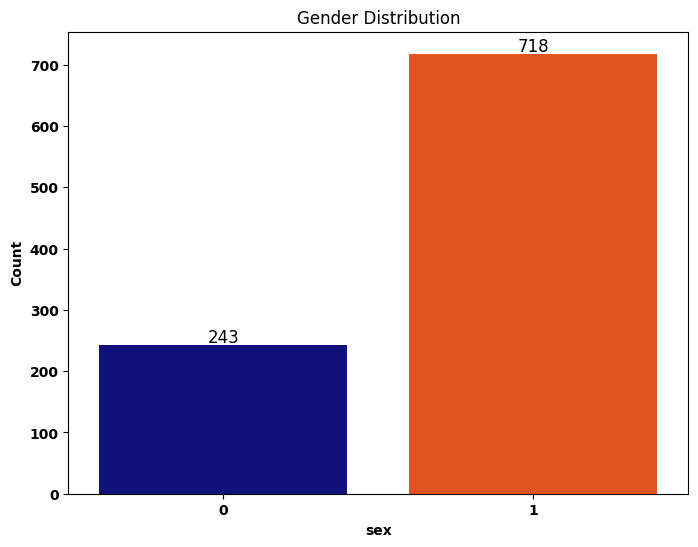

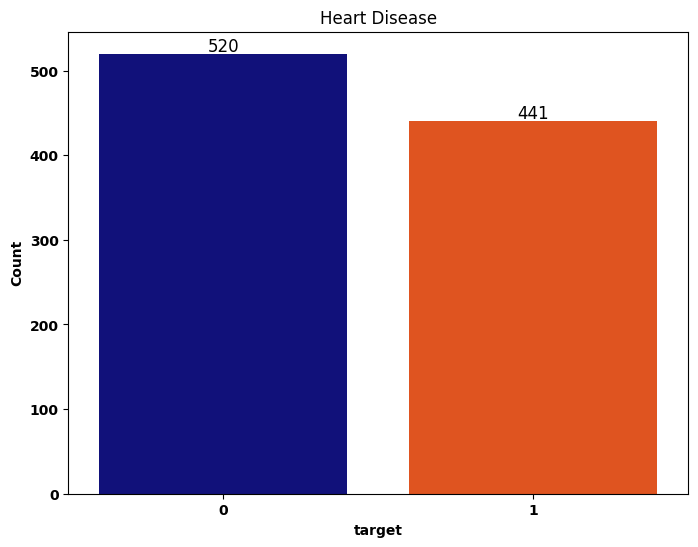

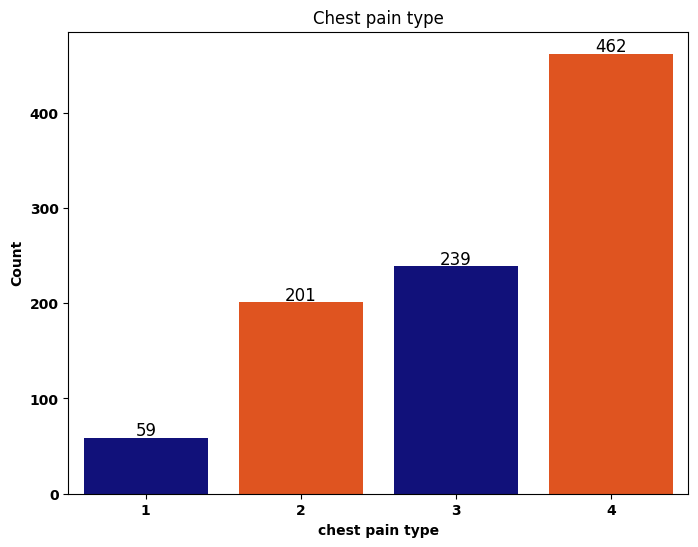

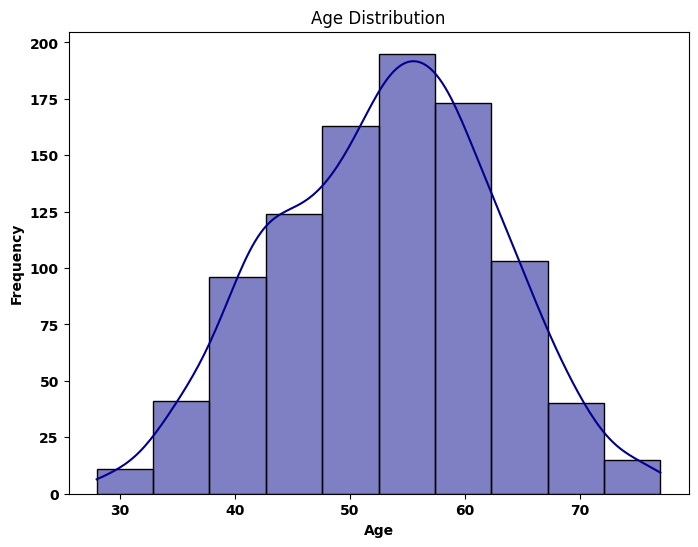

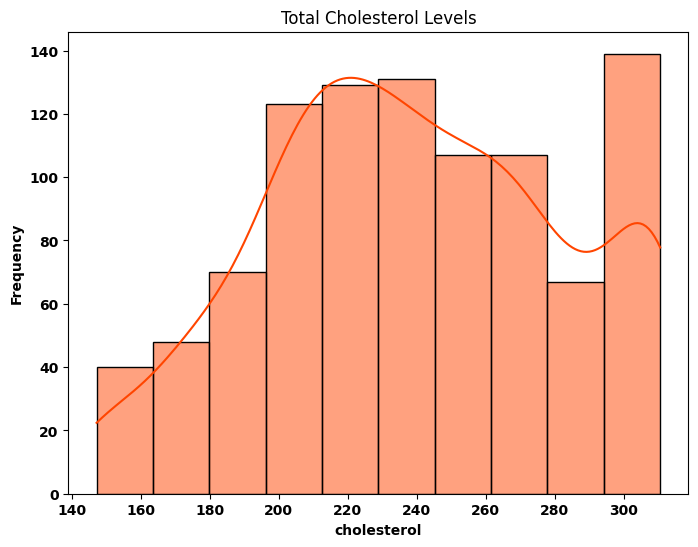

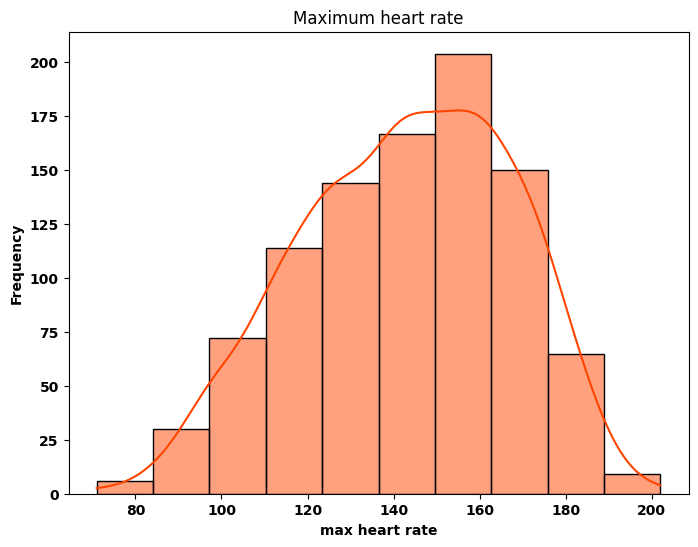

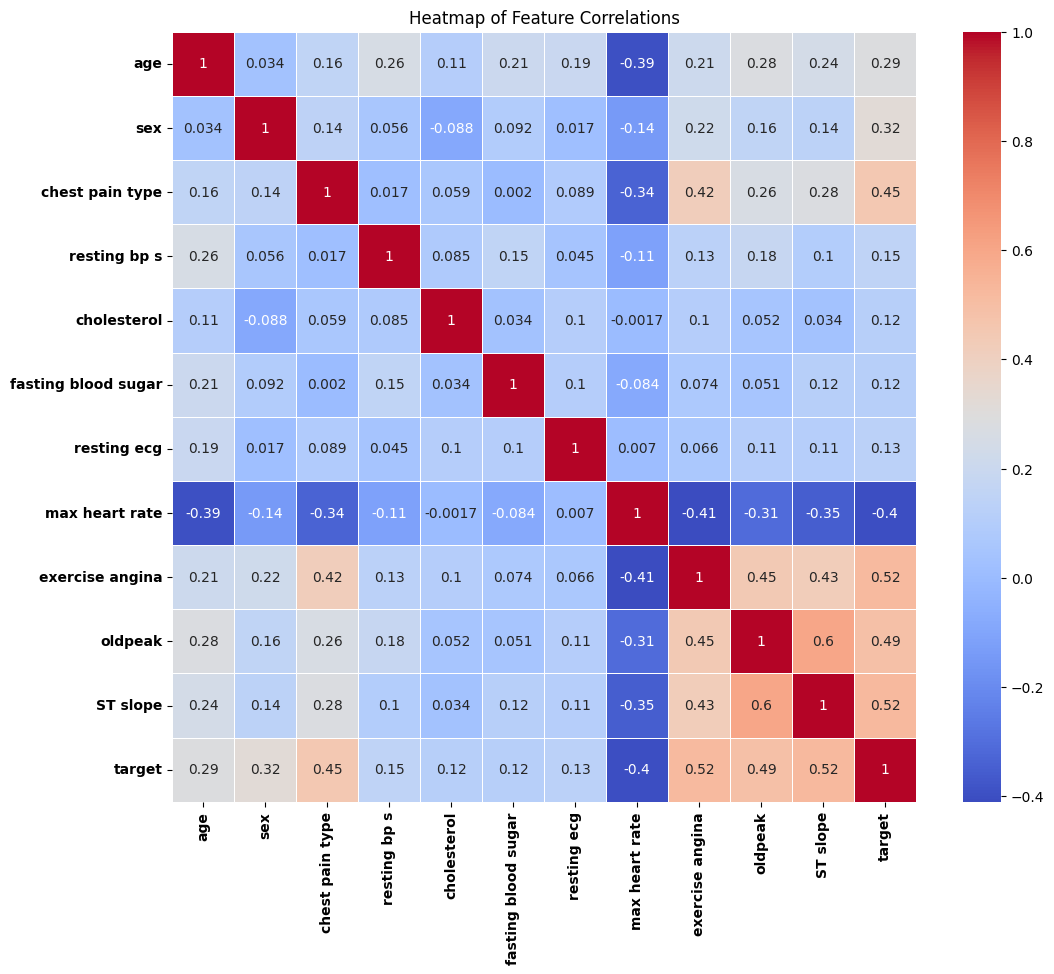

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# Set a consistent color palette
dark_blue_orange_palette = ['#00008B', '#FF4500']

# Function to annotate counts on bar plots
def annotate_counts(ax):
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='center', fontsize=12, color='black', xytext=(0, 5),
                    textcoords='offset points')

# Function to set Times New Roman font
def set_font(ax):
    for label in (ax.get_xticklabels() + ax.get_yticklabels()):

        label.set_fontsize(10)
        label.set_fontweight('bold')
    ax.set_xlabel(ax.get_xlabel(), fontsize=10, fontweight='bold')
    ax.set_ylabel(ax.get_ylabel(), fontsize=10, fontweight='bold')
    ax.set_title(ax.get_title(), fontsize=10, fontweight='bold')

# Gender Distribution Bar Chart
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='sex', data=df, palette=dark_blue_orange_palette)
annotate_counts(ax)
set_font(ax)
ax.set_title('Gender Distribution')
ax.set_xlabel('sex')
ax.set_ylabel('Count')
plt.show()

# Blood Pressure Medications Usage Bar Chart
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='target', data=df, palette=dark_blue_orange_palette)
annotate_counts(ax)
set_font(ax)
ax.set_title('Heart Disease')
ax.set_xlabel('target')
ax.set_ylabel('Count')
plt.show()

# Stroke Incidence Bar Chart
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='chest pain type', data=df, palette=dark_blue_orange_palette)
annotate_counts(ax)
set_font(ax)
ax.set_title('Chest pain type')
ax.set_xlabel('chest pain type')
ax.set_ylabel('Count')
plt.show()




# Age Distribution Histogram
plt.figure(figsize=(8, 6))
ax = sns.histplot(df['age'], kde=True, color=dark_blue_orange_palette[0], bins=10)
set_font(ax)
ax.set_title('Age Distribution')
ax.set_xlabel('Age')
ax.set_ylabel('Frequency')
plt.show()


plt.figure(figsize=(8, 6))
ax = sns.histplot(df['cholesterol'], kde=True, color=dark_blue_orange_palette[1], bins=10)
set_font(ax)
ax.set_title('Total Cholesterol Levels')
ax.set_xlabel('cholesterol')
ax.set_ylabel('Frequency')
plt.show()



# Systolic Blood Pressure Histogram
plt.figure(figsize=(8, 6))
ax = sns.histplot(df['max heart rate'], kde=True, color=dark_blue_orange_palette[1], bins=10)
set_font(ax)
ax.set_title('Maximum heart rate')
ax.set_xlabel('max heart rate')
ax.set_ylabel('Frequency')
plt.show()


# Heatmap of Feature Correlations
plt.figure(figsize=(12, 10))
corr_matrix = df.corr()
ax = sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
set_font(ax)
ax.set_title('Heatmap of Feature Correlations')
plt.show()


In [ ]:
categorical_val = []
continous_val = []
for column in df.columns:
    if len(df[column].unique()) <= 10:
        categorical_val.append(column)
    else:
        continous_val.append(column)

In [ ]:
categorical_val

['sex',
 'chest pain type',
 'fasting blood sugar',
 'resting ecg',
 'exercise angina',
 'ST slope',
 'target']

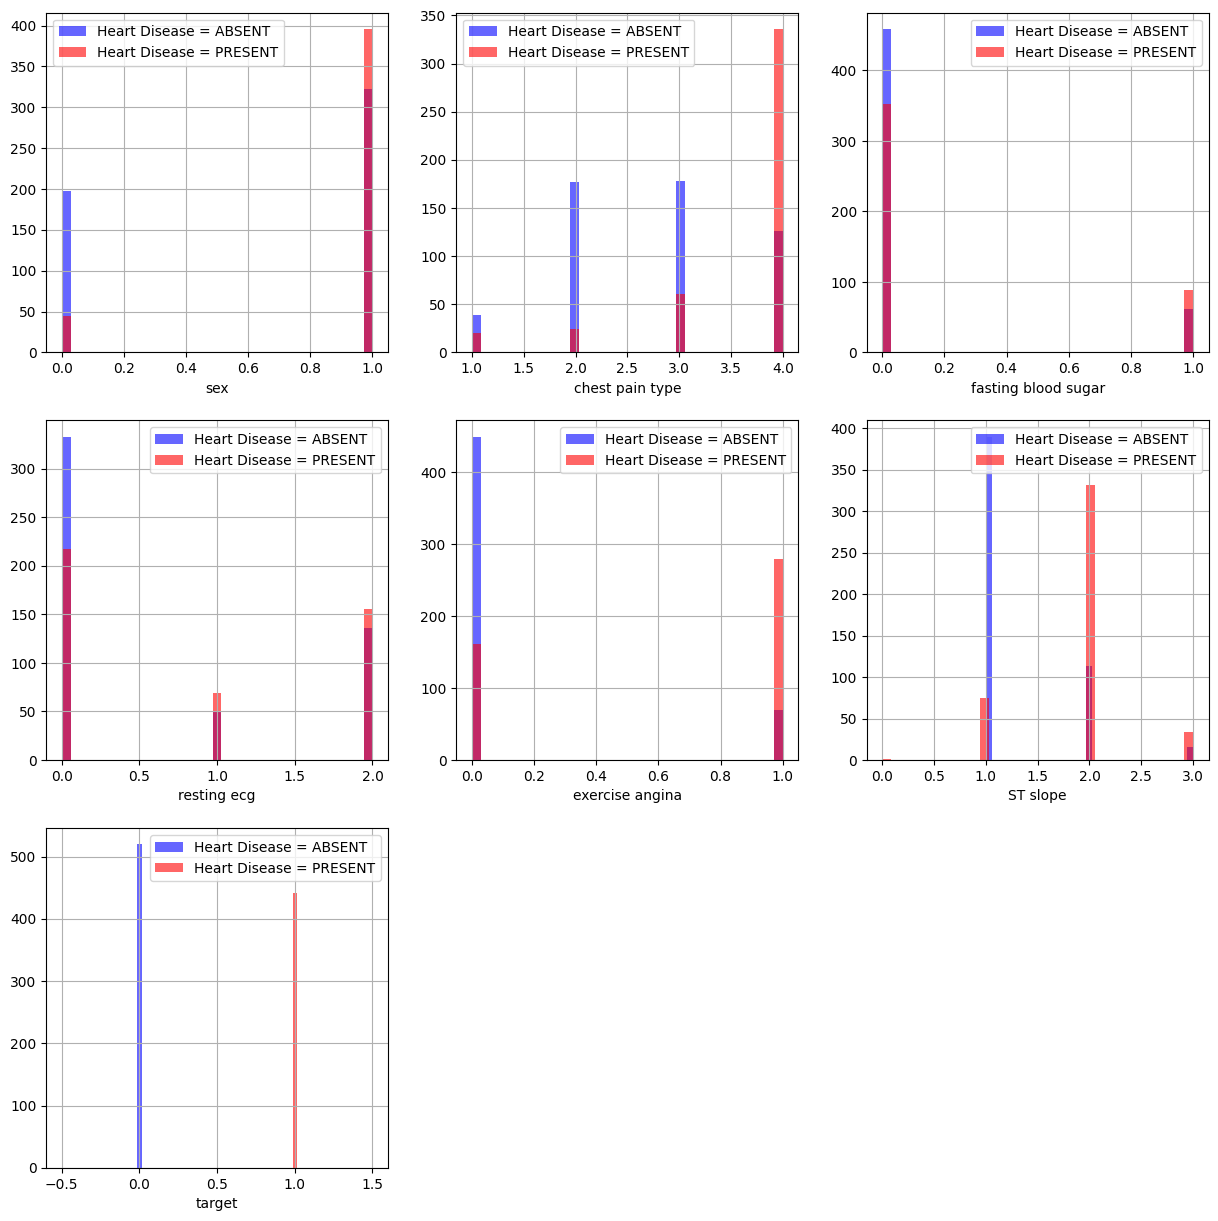

In [ ]:
plt.figure(figsize=(15, 15))

for i, column in enumerate(categorical_val, 1):
    plt.subplot(3, 3, i)
    df[df["target"] == 0][column].hist(bins=35, color='blue', label='Heart Disease = ABSENT', alpha=0.6)
    df[df["target"] == 1][column].hist(bins=35, color='red', label='Heart Disease = PRESENT', alpha=0.6)
    plt.legend()
    plt.xlabel(column)

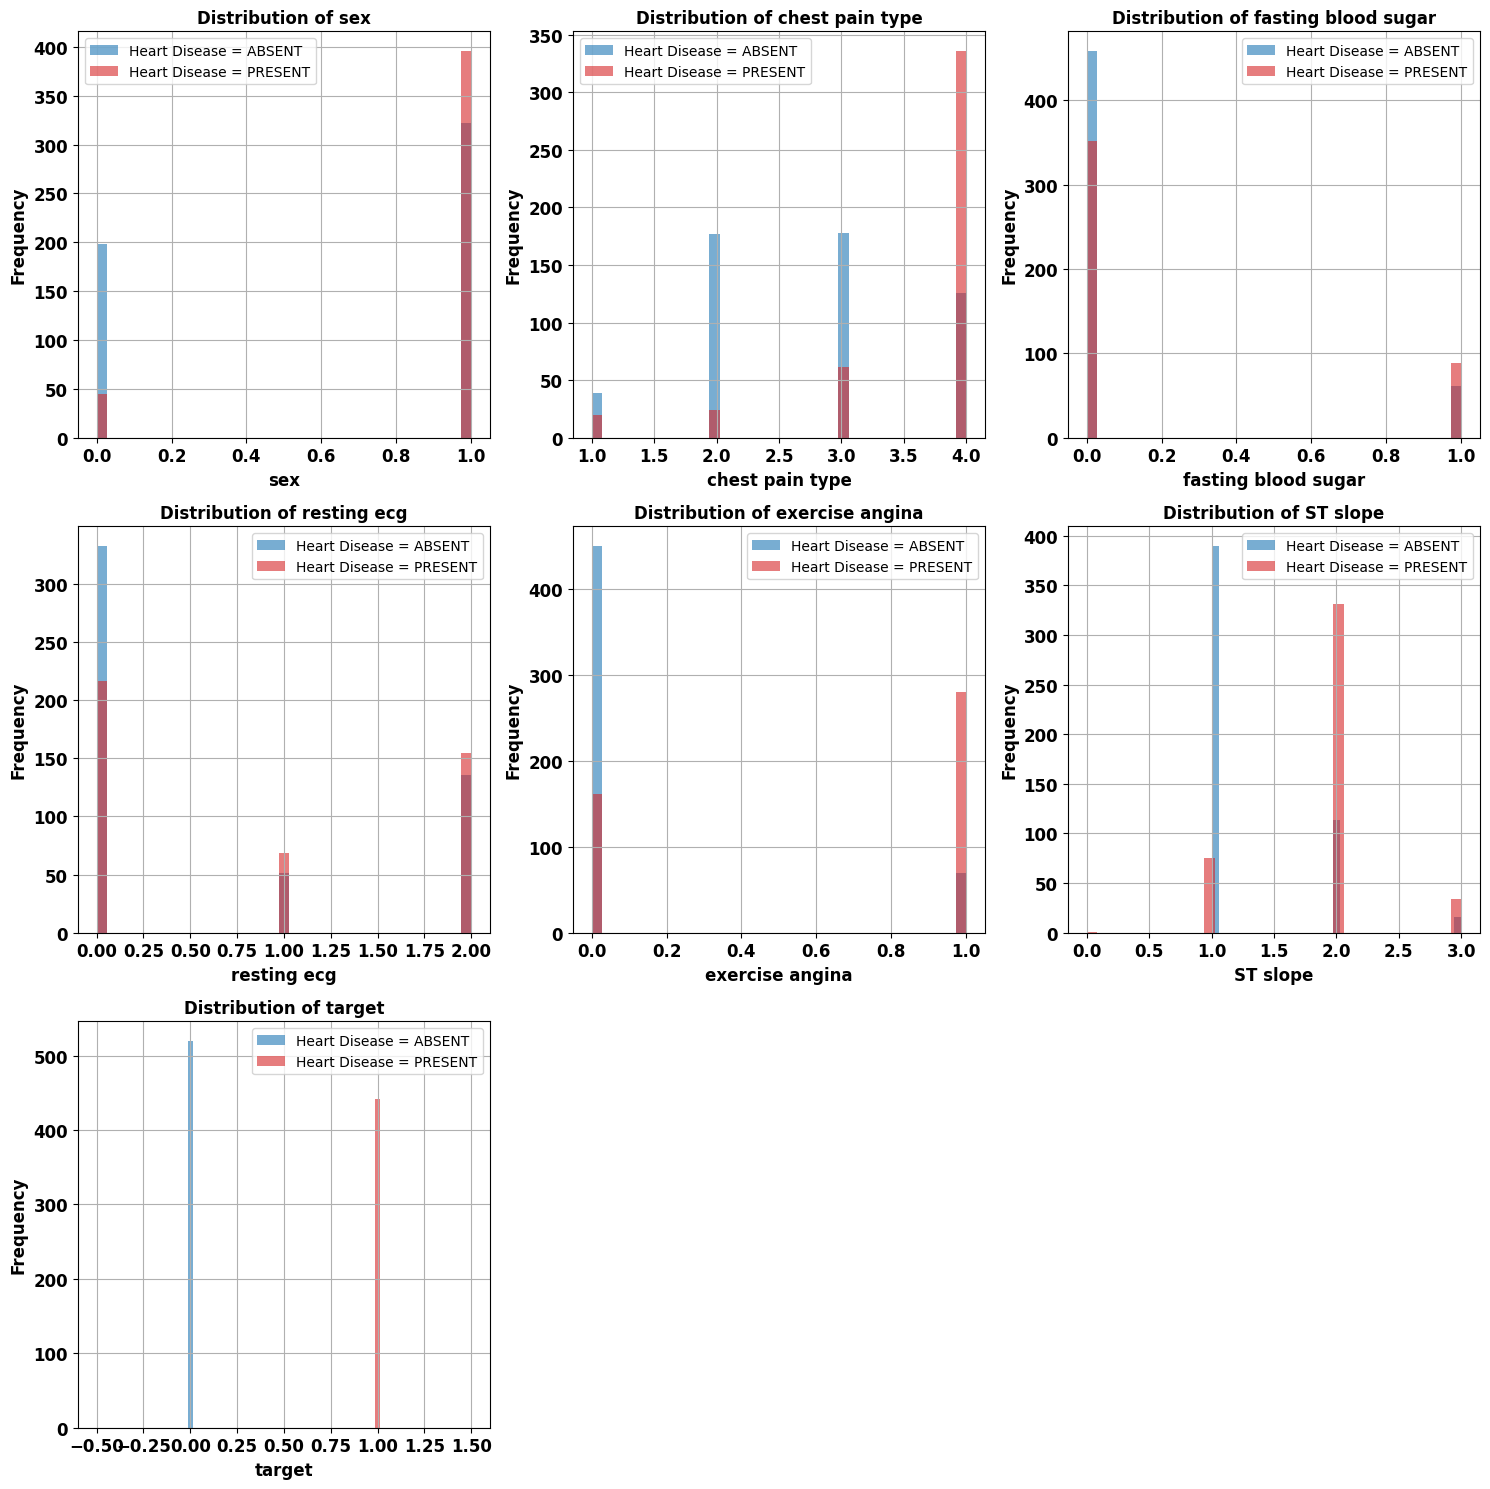

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 15))

# Ensure font settings
font = {'size': 12, 'weight': 'bold'}

for i, column in enumerate(categorical_val, 1):
    plt.subplot(3, 3, i)
    df[df["target"] == 0][column].hist(bins=35, color='#1f77b4', label='Heart Disease = ABSENT', alpha=0.6)
    df[df["target"] == 1][column].hist(bins=35, color='#d62728', label='Heart Disease = PRESENT', alpha=0.6)
    plt.legend()
    plt.xlabel(column, fontdict=font)
    plt.ylabel('Frequency', fontdict=font)
    plt.title(f'Distribution of {column}', fontdict=font)
    plt.xticks(fontsize=12, fontweight='bold')
    plt.yticks(fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


In [ ]:
unique_vals=[]

for col in df.columns:
    unival=df[col].nunique()
    unique_vals.append(unival)

#Presenting the findings using a dataframe
pd.DataFrame(unique_vals,columns=['Unique_Values'],index=df.columns)

,Unique_Values
age,49
sex,2
chest pain type,4
resting bp s,35
cholesterol,153
fasting blood sugar,2
resting ecg,3
max heart rate,106
exercise angina,2
oldpeak,27


def get_fisher_score(df,label,k = 30):
    score = fisher_score.fisher_score(data_normal_scale, y)
    #print(score)
    ranking = fisher_score.feature_ranking(score)
    #print(idx)
    
    
    dfscores = pd.DataFrame(score)
    dfcolumns = pd.DataFrame(data.columns)
    #df_rank =pd.DataFrame(idx)
    
    featureScores = pd.concat([dfcolumns,dfscores],axis=1)
    featureScores.columns = ['Feature','Score']  #naming the dataframe columns
    #print(featureScores.nlargest(k,'Score'))  #print 20 best features
    result = featureScores.nlargest(k,'Score')
    
    return result, ranking

In [ ]:
# --- Creating Dummy Variables for cp, thal and slope ---
cp = pd.get_dummies(df['chest pain type'], prefix='chest pain type')
ecg = pd.get_dummies(df['resting ecg'], prefix='resting ecg')
slope = pd.get_dummies(df['ST slope'], prefix='ST slope')

# --- Merge Dummy Variables to Main Data Frame ---
frames = [df, cp, ecg, slope]
df = pd.concat(frames, axis = 1)

In [ ]:
df = df.drop(columns = ['chest pain type', 'resting ecg', 'ST slope'])

In [ ]:
df.head(2)

,age,sex,resting bp s,cholesterol,fasting blood sugar,max heart rate,exercise angina,oldpeak,target,chest pain type_1,chest pain type_2,chest pain type_3,chest pain type_4,resting ecg_0,resting ecg_1,resting ecg_2,ST slope_0,ST slope_1,ST slope_2,ST slope_3
0,40,1,140.0,289.0,0,172,0,0.0,0,False,True,False,False,True,False,False,False,True,False,False
1,49,0,150.0,180.0,0,156,0,1.0,1,False,False,True,False,True,False,False,False,False,True,False


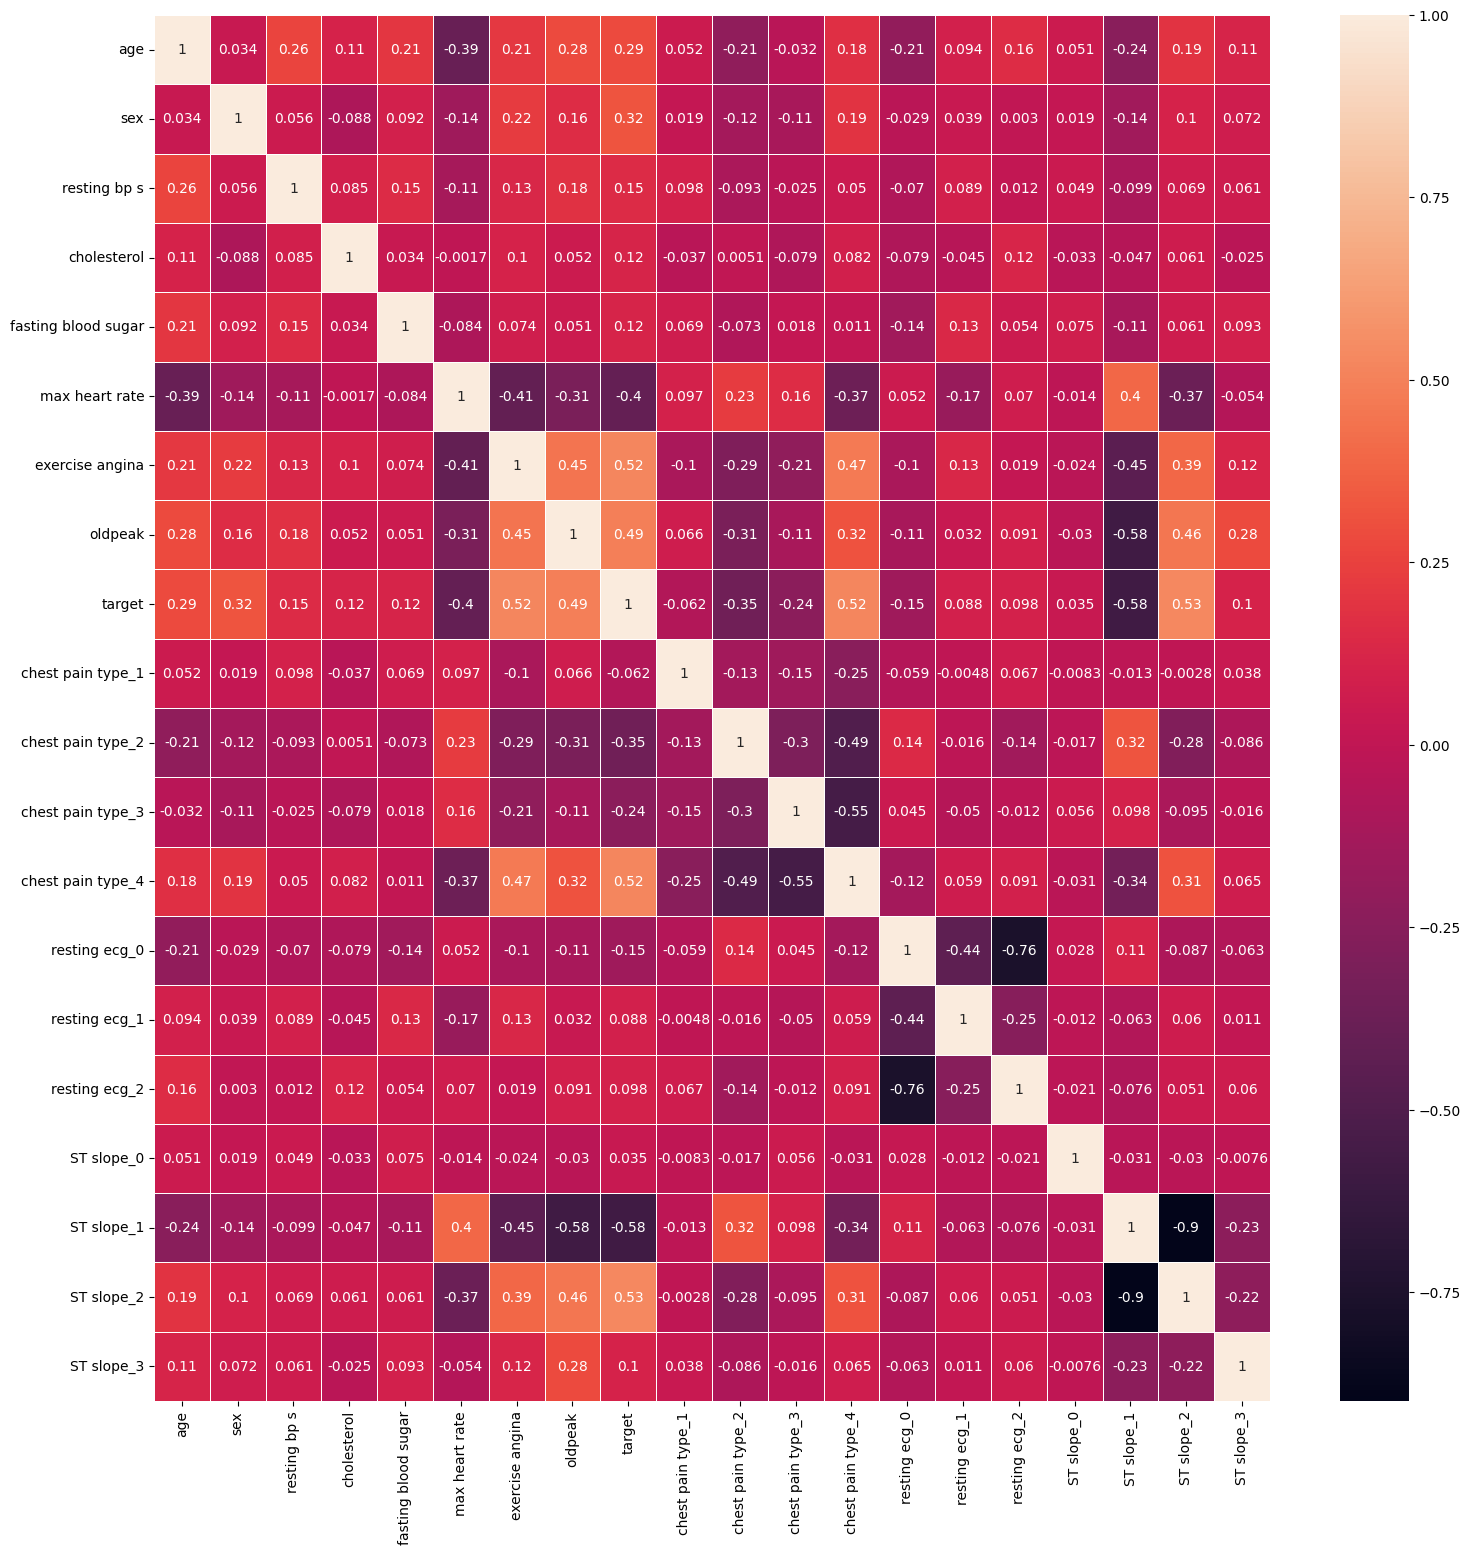

In [ ]:
#displaying correlation matrix
fig, ax = plt.subplots(figsize = (18,18))
sns.heatmap(df.corr(), annot = True, linewidths = .5, ax = ax)
plt.show()

In [ ]:
print(df.corr()["target"].sort_values(ascending=False))

target                 1.000000
ST slope_2             0.530989
chest pain type_4      0.518223
exercise angina        0.518085
oldpeak                0.488353
sex                    0.319549
age                    0.285016
resting bp s           0.147689
cholesterol            0.116761
fasting blood sugar    0.116026
ST slope_3             0.103950
resting ecg_2          0.097537
resting ecg_1          0.088011
ST slope_0             0.035047
chest pain type_1     -0.061545
resting ecg_0         -0.149390
chest pain type_3     -0.235154
chest pain type_2     -0.350369
max heart rate        -0.402171
ST slope_1            -0.578270
Name: target, dtype: float64


In [ ]:
df.to_csv('updated_preprocessed_da.csv', index=False)

In [ ]:
from sklearn.model_selection import train_test_split
from matplotlib import pyplot
X = df.drop("target",axis=1)
y = df["target"]

X_train, X_test, y_train, y_test =  train_test_split(X,y,test_size = 0.20, random_state= 42,stratify=df['target'])

In [ ]:
X_train.shape

(768, 19)

In [ ]:
X_test.shape

(193, 19)

In [ ]:
y_train.shape

(768,)

In [ ]:
y_test.shape

(193,)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RepeatedStratifiedKFold,GridSearchCV,StratifiedKFold
sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

In [ ]:
import xgboost as xgb

modelXGB = xgb.XGBClassifier(objective="binary:logistic", max_depth =14, min_child_weight=2, random_state=42)
#{'colsample_bytree': 0.5396973480251488, 'gamma': 2.766351652846777, 'max_depth': 14.0, 'min_child_weight': 2.0, 'reg_alpha': 41.0, 'reg_lambda': 0.31155004865417435}
modelXGB.fit(X_train, y_train)

y_pred = modelXGB.predict(X_test)
print('Accuracy Score:', metrics.accuracy_score(y_test,y_pred))

Accuracy Score: 0.9326424870466321


In [ ]:
from hyperopt import STATUS_OK, Trials, fmin, hp, tpe
space={'max_depth': hp.quniform("max_depth", 3, 18, 1),
        'gamma': hp.uniform ('gamma', 1,9),
        'reg_alpha' : hp.quniform('reg_alpha', 40,180,1),
        'reg_lambda' : hp.uniform('reg_lambda', 0,1),
        'colsample_bytree' : hp.uniform('colsample_bytree', 0.5,1),
        'min_child_weight' : hp.quniform('min_child_weight', 0, 10, 1),
        'n_estimators': 180,
        'seed': 0
    }

In [ ]:
def objective(space):
    clf=xgb.XGBClassifier(
                    n_estimators =space['n_estimators'], max_depth = int(space['max_depth']), gamma = space['gamma'],
                    reg_alpha = int(space['reg_alpha']),min_child_weight=int(space['min_child_weight']),
                    colsample_bytree=int(space['colsample_bytree']))

    evaluation = [( X_train, y_train), ( X_test, y_test)]

    clf.fit(X_train, y_train,
            eval_set=evaluation, eval_metric="auc",
            early_stopping_rounds=10,verbose=False)


    pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, pred>0.5)
    print ("SCORE:", accuracy)
    return {'loss': -accuracy, 'status': STATUS_OK }

In [ ]:
trials = Trials()

best_hyperparams = fmin(fn = objective,
                        space = space,
                        algo = tpe.suggest,
                        max_evals = 100,
                        trials = trials)

  0%|          | 0/100 [00:00<?, ?trial/s, best loss=?]

ERROR:hyperopt.fmin:job exception: XGBClassifier.fit() got an unexpected keyword argument 'eval_metric'


  0%|          | 0/100 [00:00<?, ?trial/s, best loss=?]


TypeError: XGBClassifier.fit() got an unexpected keyword argument 'eval_metric'

In [ ]:
print("The best hyperparameters are : ","\n")
print(best_hyperparams)

In [ ]:
scoring = {'accuracy' : make_scorer(accuracy_score),
           'precision' : make_scorer(precision_score),
           'recall' : make_scorer(recall_score),
           'f1_score' : make_scorer(f1_score)}

stratifyKF=StratifiedKFold(n_splits=20,random_state=42,shuffle=True)
XGB_score= cross_validate(modelXGB, X_train, y_train, cv=stratifyKF,scoring=scoring)
print(XGB_score)

print('accuracy',np.mean(XGB_score['test_accuracy']))
print('precision',np.mean(XGB_score['test_precision']))
print('recall',np.mean(XGB_score['test_recall']))
print('f1 score',np.mean(XGB_score['test_f1_score']))

{'fit_time': array([0.12884712, 0.12758732, 0.13119245, 0.12980747, 1.004668  ,
       0.04848886, 0.05121994, 0.04560447, 0.04758167, 0.04618359,
       0.04513669, 0.04765248, 0.04953623, 0.04723573, 0.06974101,
       0.04486299, 0.05630016, 0.0456109 , 0.04562521, 0.04474425]), 'score_time': array([0.03068376, 0.02040696, 0.01355648, 0.03020406, 0.0117538 ,
       0.01171708, 0.01163816, 0.01140308, 0.01144099, 0.01170278,
       0.017735  , 0.01174331, 0.01126599, 0.01125026, 0.01257133,
       0.01104021, 0.01161718, 0.01114678, 0.01144433, 0.01102233]), 'test_accuracy': array([0.92307692, 0.87179487, 1.        , 0.94871795, 0.8974359 ,
       0.94871795, 0.8974359 , 0.97435897, 0.97368421, 0.84210526,
       0.94736842, 0.89473684, 0.89473684, 0.94736842, 0.92105263,
       0.84210526, 0.89473684, 0.92105263, 0.89473684, 0.94736842]), 'test_precision': array([0.89473684, 0.88235294, 1.        , 0.94444444, 0.9375    ,
       1.        , 0.85      , 1.        , 0.94736842, 0.8   

In [ ]:
#feature importance using XGBoost
xgb.plot_importance(modelXGB).set_yticklabels(['age', 'sex', 'resting bp s', 'cholesterol', 'fasting blood sugar',
       'max heart rate', 'exercise angina', 'oldpeak',
       'chest pain type_1', 'chest pain type_2', 'chest pain type_3',
       'chest pain type_4', 'resting ecg_0', 'resting ecg_1', 'resting ecg_2',
       'ST slope_0', 'ST slope_1', 'ST slope_2', 'ST slope_3'])
plt.rcParams['figure.figsize'] = [6, 6]
plt.show()

[0.07149033 0.06482895 0.06346234 0.06301175 0.01551797 0.07382836
 0.09687556 0.08579079 0.00954866 0.02763335 0.01724071 0.09663672
 0.01531378 0.0121194  0.02454013 0.00098265 0.16081115 0.09313931
 0.00722808]


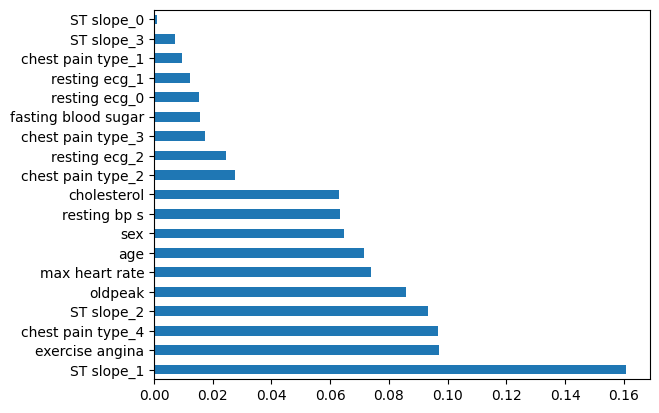

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier
import matplotlib.pyplot as plt

modelex = ExtraTreesClassifier(n_estimators= 100,
 min_samples_split=2,
 min_samples_leaf = 1,
 max_features= 'sqrt',
 max_depth=52,
 bootstrap= False)
modelex.fit(X_train, y_train)
print(modelex.feature_importances_) #use inbuilt class feature_importances of tree based classifiers
feat_importances = pd.Series(modelex.feature_importances_, index=X.columns)
feat_importances.nlargest(20).plot(kind='barh')
plt.show()

In [ ]:
scoring = {'accuracy' : make_scorer(accuracy_score),
           'precision' : make_scorer(precision_score),
           'recall' : make_scorer(recall_score),
           'f1_score' : make_scorer(f1_score)}

stratifyKF=StratifiedKFold(n_splits=30,random_state=42,shuffle=True)
ex_score= cross_validate(modelex, X_train, y_train, cv=stratifyKF,scoring=scoring)
print(ex_score)

print('accuracy',np.mean(ex_score['test_accuracy']))
print('precision',np.mean(ex_score['test_precision']))
print('recall',np.mean(ex_score['test_recall']))
print('f1 score',np.mean(ex_score['test_f1_score']))

{'fit_time': array([0.1548748 , 0.14354277, 0.14079213, 0.14036989, 0.14900422,
       0.15110397, 0.13781762, 0.13800669, 0.13812351, 0.14403915,
       0.14044833, 0.13785911, 0.15332222, 0.13738966, 0.13954878,
       0.14352059, 0.13744259, 0.13783503, 0.15322828, 0.14429235,
       0.14069915, 0.13878608, 0.13716102, 0.14384985, 0.14273405,
       0.14954329, 0.1373024 , 0.1465199 , 0.1372838 , 0.1410439 ]), 'score_time': array([0.01291776, 0.0148046 , 0.01232791, 0.01281738, 0.0124197 ,
       0.01565576, 0.01294684, 0.01304746, 0.01233411, 0.01245594,
       0.01241589, 0.0121243 , 0.01240444, 0.01267648, 0.01312208,
       0.01231813, 0.0124681 , 0.01225758, 0.01510954, 0.01231837,
       0.01262569, 0.01783156, 0.01232219, 0.01245046, 0.01257396,
       0.01308846, 0.01293898, 0.01238465, 0.01260543, 0.0159049 ]), 'test_accuracy': array([0.88461538, 0.80769231, 0.88461538, 0.96153846, 0.96153846,
       0.96153846, 0.92307692, 0.96153846, 0.92307692, 0.88461538,
       0.96153

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from pprint import pprint
# Number of trees in random forest
n_estimators = [int(x) for x in np.linspace(start = 5, stop = 100, num = 5)]
# Number of features to consider at every split
max_features = ['auto', 'sqrt']
# Maximum number of levels in tree
max_depth = [int(x) for x in np.linspace(4, 100, num = 5)]
max_depth.append(None)
# Minimum number of samples required to split a node
min_samples_split = [2, 5, 10]
# Minimum number of samples required at each leaf node
min_samples_leaf = [1, 2, 4]
# Method of selecting samples for training each tree
bootstrap = [True, False]
# Create the random grid
ex_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}
pprint(ex_grid)


{'bootstrap': [True, False],
 'max_depth': [4, 28, 52, 76, 100, None],
 'max_features': ['auto', 'sqrt'],
 'min_samples_leaf': [1, 2, 4],
 'min_samples_split': [2, 5, 10],
 'n_estimators': [5, 28, 52, 76, 100]}


In [ ]:
ex_random = RandomizedSearchCV(estimator = modelex, param_distributions = ex_grid, n_iter = 10, cv = 5, verbose=2, random_state=42, n_jobs = -1)
# Fit the random search model
ex_random.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5, estimator=ExtraTreesClassifier(max_depth=52),
                   n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [4, 28, 52, 76, 100, None],
                                        'max_features': ['auto', 'sqrt'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [5, 28, 52, 76, 100]},
                   random_state=42, verbose=2)

In [ ]:
ex_random.best_params_

{'n_estimators': 100,
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': None,
 'bootstrap': False}

In [ ]:
ex_random.best_score_

0.9140140904846786

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
class_names = [0, 1]

In [ ]:
def print_metric():
  # print('Confusion Matrix - Train: ', '\n', confusion_matrix(y_train, y_pred_train))
  # print('\n Accuracy - Train: ', accuracy_score(y_train, y_pred_train))
  print("Accuracy - Test: ",accuracy_score(y_test, y_pred))
  print('confusion matrix - Test  :',confusion_matrix(y_test, y_pred))
  print('mean absolute error  model: ',mean_absolute_error(y_test, y_pred))
  print('\nClassification report for test:\n',classification_report(y_test,y_pred))

In [ ]:
def metric_calc(y_test, y_pred):
  print('\n before oversampling..')
  CM = confusion_matrix(y_test, y_pred)
  disp = ConfusionMatrixDisplay(confusion_matrix=CM, display_labels=class_names)
  disp.plot(cmap='Blues')
  plt.title('Confusion Matrix')
  plt.show()


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import train_test_split,GridSearchCV

modelNB = GaussianNB(var_smoothing=1.0)

modelNB.fit(X_train, y_train)
y_pred  =  modelNB.predict(X_test)
print('Naive Bayes')
metric_calc(y_test,y_pred)
print_metric()

Naive Bayes
 Specificity or true negative rate : 0.8269230769230769
Confusion Matrix - Train:  
 [[416   0]
 [  0 352]]

 Accuracy - Train:  1.0
Accuracy - Test:  0.7979274611398963
confusion matrix - Test  : [[86 18]
 [21 68]]
mean absolute error  model:  0.20207253886010362

Classification report for test:
               precision    recall  f1-score   support

           0       0.80      0.83      0.82       104
           1       0.79      0.76      0.78        89

    accuracy                           0.80       193
   macro avg       0.80      0.80      0.80       193
weighted avg       0.80      0.80      0.80       193



In [ ]:
#fit into DT model
from sklearn.tree import DecisionTreeClassifier
modelDT_basic = DecisionTreeClassifier()
modelDT_basic = modelDT_basic.fit(X_train,y_train)
#prediction with DT
y_pred = modelDT_basic.predict(X_test)  #Accuracy
from sklearn import metrics
print('Accuracy Score:', metrics.accuracy_score(y_test,y_pred))

Accuracy Score: 0.8549222797927462


In [ ]:
cols =['age', 'sex', 'chest pain type', 'resting bp s', 'cholesterol',
       'fasting blood sugar', 'resting ecg', 'max heart rate',
       'exercise angina', 'oldpeak', 'ST slope', 'target']

In [ ]:
print(df.corr()["target"].abs().sort_values(ascending=False))

target                 1.000000
ST slope_1             0.578270
ST slope_2             0.530989
chest pain type_4      0.518223
exercise angina        0.518085
oldpeak                0.488353
max heart rate         0.402171
chest pain type_2      0.350369
sex                    0.319549
age                    0.285016
chest pain type_3      0.235154
resting ecg_0          0.149390
resting bp s           0.147689
cholesterol            0.116761
fasting blood sugar    0.116026
ST slope_3             0.103950
resting ecg_2          0.097537
resting ecg_1          0.088011
chest pain type_1      0.061545
ST slope_0             0.035047
Name: target, dtype: float64


In [ ]:
def print_metric():
  print('Confusion Matrix - Train: ', '\n', confusion_matrix(y_train, y_pred_train))
  print('\n Accuracy - Train: ', accuracy_score(y_train, y_pred_train))
  print("Accuracy - Test: ",metrics.accuracy_score(y_test, y_pred))
  print('confusion matrix - Test  :',confusion_matrix(y_test, y_pred))
  print('mean absolute error  model: ',mean_absolute_error(y_test, y_pred))
  print('\nClassification report for test:\n',classification_report(y_test,y_pred))

In [ ]:
def metric_calc(y_test, y_pred):

  CM = confusion_matrix(y_test, y_pred)

  TN = CM[0][0]
  FN = CM[1][0]
  TP = CM[1][1]
  FP = CM[0][1]
  # Sensitivity, hit rate, recall, or true positive rate
  TPR = TP/(TP+FN)
  #print('sensitivity/true positive rate/recall :',TPR)
  # Specificity or true negative rate
  TNR = TN/(TN+FP)
  print(' Specificity or true negative rate :',TNR)
  # Precision or positive predictive value
  PPV = TP/(TP+FP)
  #print('precision/positive predict value:',PPV)
  #F1 score
  F1= 2*((PPV*TPR)/(PPV+TPR))
  #print('F1 score :',F1)

**DECISION TREE**

In [ ]:

modelDT = DecisionTreeClassifier(criterion="entropy", max_depth=15,min_samples_split=2)
modelDT = modelDT.fit(X_train,y_train)#Predict the response for test dataset
y_pred = modelDT.predict(X_test)# Model Accuracy, how often is the classifier correct?
y_pred_train = modelDT.predict (X_train)
print('\n DECISION TREE')
metric_calc(y_test, y_pred)
print_metric()



 DECISION TREE
 Specificity or true negative rate : 0.8942307692307693
Confusion Matrix - Train:  
 [[416   0]
 [  0 352]]

 Accuracy - Train:  1.0
Accuracy - Test:  0.8497409326424871
confusion matrix - Test  : [[93 11]
 [18 71]]
mean absolute error  model:  0.15025906735751296

Classification report for test:
               precision    recall  f1-score   support

           0       0.84      0.89      0.87       104
           1       0.87      0.80      0.83        89

    accuracy                           0.85       193
   macro avg       0.85      0.85      0.85       193
weighted avg       0.85      0.85      0.85       193



In [ ]:
df_classifier = DecisionTreeClassifier(random_state=42)

params_DT = {'criterion': ['gini', 'entropy'],
             'max_depth': [1, 2, 3, 4, 5, 6, 7, 8,15,25],
             'min_samples_split': [2, 3]}

cv_method = RepeatedStratifiedKFold(n_splits=10,
                                    n_repeats=3,
                                    random_state=42)
gs_DT = GridSearchCV(estimator=df_classifier,
                     param_grid=params_DT,
                     cv=cv_method,
                     verbose=1,
                     scoring='accuracy')

gs_DT.fit(X_train,y_train);

Fitting 30 folds for each of 40 candidates, totalling 1200 fits


In [ ]:
gs_DT.best_params_

{'criterion': 'entropy', 'max_depth': 15, 'min_samples_split': 2}

In [ ]:
gs_DT.best_score_

0.8828548644338118

In [ ]:
results_DT = pd.DataFrame(gs_DT.cv_results_['params'])
results_DT['test_score'] = gs_DT.cv_results_['mean_test_score']
results_DT.columns

Index(['criterion', 'max_depth', 'min_samples_split', 'test_score'], dtype='object')

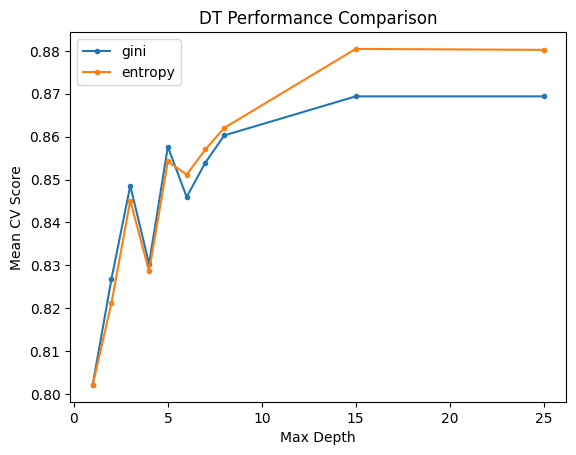

In [ ]:
for i in ['gini', 'entropy']:
    temp = results_DT[results_DT['criterion'] == i]
    temp_average = temp.groupby('max_depth').agg({'test_score': 'mean'})
    plt.plot(temp_average, marker = '.', label = i)


plt.legend()
plt.xlabel('Max Depth')
plt.ylabel("Mean CV Score")
plt.title("DT Performance Comparison")
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score,StratifiedKFold

In [ ]:
scoring = {'accuracy' : make_scorer(accuracy_score),
           'precision' : make_scorer(precision_score),
           'recall' : make_scorer(recall_score),
           'f1_score' : make_scorer(f1_score)}
stratifiedkf=StratifiedKFold(n_splits=20,random_state=42,shuffle=True)
#cv = KFold(n_splits=10, random_state=1, shuffle=True)
DT_score = cross_validate(modelDT, X_train, y_train, cv=stratifiedkf, scoring=scoring)
print(DT_score)

print('accuracy',np.mean(DT_score['test_accuracy']))
print('precision',np.mean(DT_score['test_precision']))
print('recall',np.mean(DT_score['test_recall']))
print('f1 score',np.mean(DT_score['test_f1_score']))

{'fit_time': array([0.00611973, 0.00385642, 0.00386667, 0.00363827, 0.00376177,
       0.0063355 , 0.00444746, 0.00447583, 0.00409985, 0.00375009,
       0.00370765, 0.00403547, 0.00404978, 0.0038836 , 0.00365448,
       0.00377703, 0.00375724, 0.00411606, 0.00373507, 0.00385165]), 'score_time': array([0.00847721, 0.00810814, 0.00762725, 0.00816393, 0.00834012,
       0.01019073, 0.01026392, 0.01012611, 0.00924182, 0.00743151,
       0.00761938, 0.00953746, 0.00758076, 0.00749636, 0.00861478,
       0.00761461, 0.00786042, 0.00762177, 0.0073812 , 0.00761151]), 'test_accuracy': array([0.79487179, 0.84615385, 0.97435897, 0.94871795, 0.87179487,
       0.87179487, 0.76923077, 0.92307692, 0.89473684, 0.86842105,
       0.89473684, 0.89473684, 0.86842105, 0.81578947, 0.86842105,
       0.84210526, 0.86842105, 0.89473684, 0.94736842, 0.89473684]), 'test_precision': array([0.85714286, 0.83333333, 0.94736842, 0.94444444, 0.88235294,
       0.88235294, 0.71428571, 0.94117647, 0.88888889, 0.8095

**RANDOM FOREST**





In [ ]:
from sklearn.ensemble import RandomForestClassifier

modelRF = RandomForestClassifier(n_estimators=100,max_depth=None,min_samples_leaf=1,max_features="sqrt",min_samples_split=5,bootstrap=False)
#{'bootstrap': True, 'max_depth': 10, 'max_features': 'auto', 'n_estimators': 100}
# fit the predictor and target
modelRF.fit(X_train, y_train)

# predict
y_pred = modelRF.predict(X_test)# check performance
print('ROCAUC score:',roc_auc_score(y_test, y_pred))
y_pred_train = modelRF.predict (X_train)
print("\n\n\t RANDOM CLASSIFIER")
metric_calc(y_test,y_pred)
print_metric()

ROCAUC score: 0.91740492653414


	 RANDOM CLASSIFIER
 Specificity or true negative rate : 0.9134615384615384
Confusion Matrix - Train:  
 [[416   0]
 [  0 352]]

 Accuracy - Train:  1.0
Accuracy - Test:  0.917098445595855
confusion matrix - Test  : [[95  9]
 [ 7 82]]
mean absolute error  model:  0.08290155440414508

Classification report for test:
               precision    recall  f1-score   support

           0       0.93      0.91      0.92       104
           1       0.90      0.92      0.91        89

    accuracy                           0.92       193
   macro avg       0.92      0.92      0.92       193
weighted avg       0.92      0.92      0.92       193



In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from pprint import pprint
# Number of trees in random forest
n_estimators = [int(x) for x in np.linspace(start = 5, stop = 100, num = 5)]
# Number of features to consider at every split
max_features = ['auto', 'sqrt']
# Maximum number of levels in tree
max_depth = [int(x) for x in np.linspace(4, 100, num = 5)]
max_depth.append(None)
# Minimum number of samples required to split a node
min_samples_split = [2, 5, 10]
# Minimum number of samples required at each leaf node
min_samples_leaf = [1, 2, 4]
# Method of selecting samples for training each tree
bootstrap = [True, False]
# Create the random grid
random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}
pprint(random_grid)


{'bootstrap': [True, False],
 'max_depth': [4, 28, 52, 76, 100, None],
 'max_features': ['auto', 'sqrt'],
 'min_samples_leaf': [1, 2, 4],
 'min_samples_split': [2, 5, 10],
 'n_estimators': [5, 28, 52, 76, 100]}


In [ ]:
rf_random = RandomizedSearchCV(estimator = modelRF, param_distributions = random_grid, n_iter = 10, cv = 5, verbose=2, random_state=42, n_jobs = -1)
# Fit the random search model
rf_random.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5,
                   estimator=RandomForestClassifier(bootstrap=False,
                                                    min_samples_split=5),
                   n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [4, 28, 52, 76, 100, None],
                                        'max_features': ['auto', 'sqrt'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [5, 28, 52, 76, 100]},
                   random_state=42, verbose=2)

In [ ]:
rf_random.best_params_

{'n_estimators': 100,
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': None,
 'bootstrap': False}

In [ ]:
rf_random.best_score_

0.9166454460572109

In [ ]:
scoring = {'accuracy' : make_scorer(accuracy_score),
           'precision' : make_scorer(precision_score),
           'recall' : make_scorer(recall_score),
           'f1_score' : make_scorer(f1_score)}

stratifiedkf=StratifiedKFold(n_splits=20,random_state=42,shuffle=True)
rfc_score = cross_validate(modelRF, X_train, y_train, cv=stratifiedkf,scoring=scoring)
print(rfc_score)

print('accuracy',np.mean(rfc_score['test_accuracy']))
print('precision',np.mean(rfc_score['test_precision']))
print('recall',np.mean(rfc_score['test_recall']))
print('f1 score',np.mean(rfc_score['test_f1_score']))

{'fit_time': array([0.1764617 , 0.1709547 , 0.16469097, 0.17022824, 0.18459415,
       0.16375303, 0.18757153, 0.16272449, 0.16640735, 0.16424727,
       0.16386032, 0.18824649, 0.16361523, 0.16415405, 0.16345835,
       0.16399837, 0.16590405, 0.17419982, 0.16425443, 0.15998721]), 'score_time': array([0.01323581, 0.01356697, 0.01344514, 0.01388526, 0.01310778,
       0.01285362, 0.01262665, 0.01374149, 0.01356387, 0.01383519,
       0.01494217, 0.01466203, 0.01378679, 0.01328754, 0.01258302,
       0.01376367, 0.01248765, 0.01366925, 0.01249218, 0.01244998]), 'test_accuracy': array([0.97435897, 0.87179487, 0.97435897, 0.97435897, 0.94871795,
       0.94871795, 0.8974359 , 1.        , 0.97368421, 0.86842105,
       0.92105263, 0.92105263, 0.92105263, 0.97368421, 0.92105263,
       0.84210526, 0.92105263, 0.92105263, 0.94736842, 0.94736842]), 'test_precision': array([0.94736842, 0.88235294, 0.94736842, 1.        , 1.        ,
       1.        , 0.88888889, 1.        , 0.94736842, 0.8095

**LOGISTIC REGRESSION**

In [ ]:
import shap

# Use the shap.Explainer for general model explanations
explainer = shap.Explainer(modelRF)

# Get SHAP values
shap_values = explainer.shap_values(X_test)

# Check the shapes of SHAP values
print("Shape of shap_values:", shap_values.shape)
print("Shape of X_test:", X_test.shape)


Shape of shap_values: (193, 19, 2)
Shape of X_test: (193, 19)


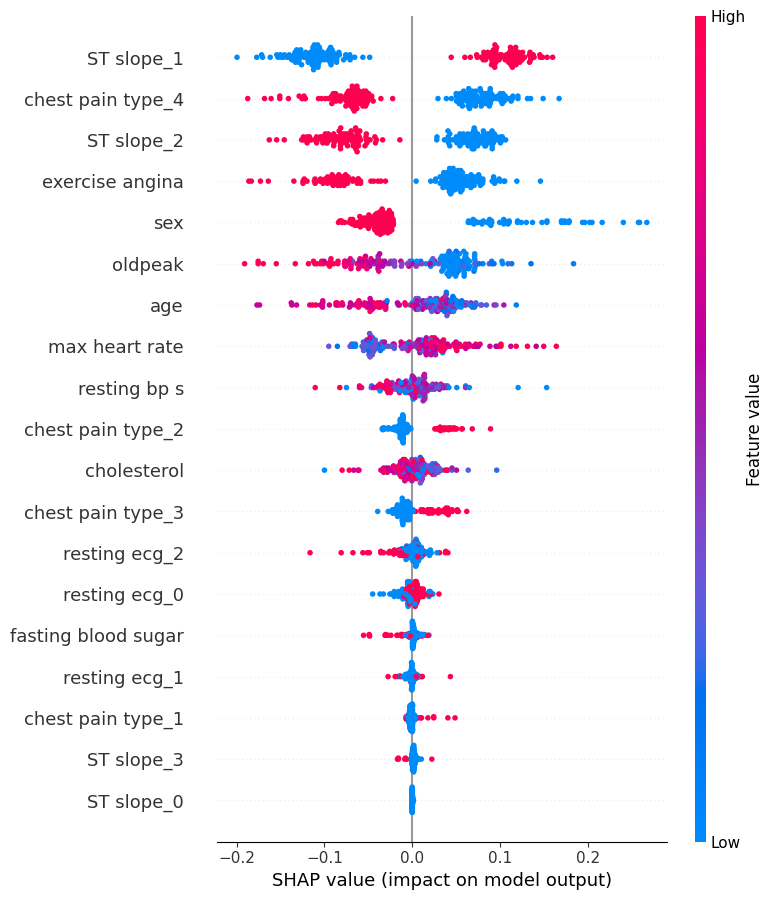

In [ ]:
# Assuming a binary classification problem, select SHAP values for class 0 or 1:
feature_names = X.columns.tolist()
shap_values_class0 = shap_values[:, :, 0]  # SHAP values for class 0

# Create the summary plot for class 0
#shap.summary_plot(shap_values_class0, X_test)
shap.summary_plot(shap_values_class0, X_test,feature_names=feature_names)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

modelLR = LogisticRegression(solver='liblinear')
modelLR.fit(X_train,y_train)

y_pred = modelLR.predict(X_test)
y_pred_train = modelLR.predict (X_train)

print("\n\n\t LOGISTIC REGRESSION")
metric_calc(y_test,y_pred)
print_metric()



	 LOGISTIC REGRESSION
 Specificity or true negative rate : 0.8365384615384616
Confusion Matrix - Train:  
 [[365  51]
 [ 51 301]]

 Accuracy - Train:  0.8671875
Accuracy - Test:  0.8186528497409327
confusion matrix - Test  : [[87 17]
 [18 71]]
mean absolute error  model:  0.18134715025906736

Classification report for test:
               precision    recall  f1-score   support

           0       0.83      0.84      0.83       104
           1       0.81      0.80      0.80        89

    accuracy                           0.82       193
   macro avg       0.82      0.82      0.82       193
weighted avg       0.82      0.82      0.82       193



In [ ]:
scoring = {'accuracy' : make_scorer(accuracy_score),
           'precision' : make_scorer(precision_score),
           'recall' : make_scorer(recall_score),
           'f1_score' : make_scorer(f1_score)}
stratifiedkf=StratifiedKFold(n_splits=20,random_state=42,shuffle=True)
#cv = KFold(n_splits=20, random_state=42, shuffle=True)
LR_score = cross_validate(modelLR, X_train, y_train, cv=stratifiedkf, scoring=scoring)
print(LR_score)

print('accuracy',np.mean(LR_score['test_accuracy']))
print('precision',np.mean(LR_score['test_precision']))
print('recall',np.mean(LR_score['test_recall']))

print('F1 score',np.mean(LR_score['test_f1_score']))

{'fit_time': array([0.00579572, 0.00306964, 0.00298309, 0.00309181, 0.0030334 ,
       0.00302529, 0.00294924, 0.00328231, 0.00304461, 0.0027647 ,
       0.00303292, 0.00359678, 0.00307536, 0.00307298, 0.00336218,
       0.0030129 , 0.00362873, 0.00297141, 0.00288582, 0.00305104]), 'score_time': array([0.01146936, 0.01246858, 0.00786972, 0.00820136, 0.00773358,
       0.00767064, 0.00767016, 0.00927782, 0.00802755, 0.00753641,
       0.00765824, 0.00850344, 0.00850487, 0.0082767 , 0.00778055,
       0.00994754, 0.00846696, 0.00755095, 0.00867438, 0.00740767]), 'test_accuracy': array([0.84615385, 0.82051282, 0.94871795, 0.8974359 , 0.8974359 ,
       0.87179487, 0.74358974, 0.8974359 , 0.92105263, 0.76315789,
       0.92105263, 0.84210526, 0.84210526, 0.84210526, 0.84210526,
       0.76315789, 0.84210526, 0.81578947, 0.94736842, 0.86842105]), 'test_precision': array([0.83333333, 0.82352941, 1.        , 1.        , 0.88888889,
       0.88235294, 0.7       , 0.85      , 0.85714286, 0.6956

KNN

In [ ]:
#k nearest neighbour  KNN model
from sklearn.neighbors import KNeighborsClassifier
modelKNN = KNeighborsClassifier(n_neighbors=29,leaf_size=1, p=1,metric='manhattan',weights='distance')
# fit the predictor and target
modelKNN.fit(X_train, y_train)
# predict
y_pred = modelKNN.predict(X_test)# check performance
y_pred_train = modelKNN.predict (X_train)
print("\n\n\t K- nearest Neighbour CLASSIFIER")
metric_calc(y_test,y_pred)
print_metric()



	 K- nearest Neighbour CLASSIFIER
 Specificity or true negative rate : 0.9038461538461539
Confusion Matrix - Train:  
 [[416   0]
 [  0 352]]

 Accuracy - Train:  1.0
Accuracy - Test:  0.9119170984455959
confusion matrix - Test  : [[94 10]
 [ 7 82]]
mean absolute error  model:  0.08808290155440414

Classification report for test:
               precision    recall  f1-score   support

           0       0.93      0.90      0.92       104
           1       0.89      0.92      0.91        89

    accuracy                           0.91       193
   macro avg       0.91      0.91      0.91       193
weighted avg       0.91      0.91      0.91       193



In [ ]:
leaf_size = list(range(1,50))
n_neighbors = list(range(1,30))
p=[1,2]
weights = ['uniform', 'distance']
metric = ['manhattan', 'minkowski']
#Convert to dictionary
hyperparameters = dict(leaf_size=leaf_size, n_neighbors=n_neighbors, p=p,weights=weights,metric=metric)
#Use GridSearch
clf = GridSearchCV(modelKNN, hyperparameters, cv=10)
#Fit the model
best_model = clf.fit(X_train, y_train)
#Print The value of best Hyperparameters
print('Best leaf_size:', best_model.best_estimator_.get_params()['leaf_size'])
print('Best p:', best_model.best_estimator_.get_params()['p'])
print('Best n_neighbors:', best_model.best_estimator_.get_params()['n_neighbors'])
print('Best weights:', best_model.best_estimator_.get_params()['weights'])
print('Best metric:', best_model.best_estimator_.get_params()['metric'])


Best leaf_size: 1
Best p: 1
Best n_neighbors: 29
Best weights: distance
Best metric: manhattan


In [ ]:
best_model.best_score_

0.9348769651401231

In [ ]:
k_range = list(range(1, 100))
k_scores = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn,  X_train, y_train, cv=10, scoring='accuracy')
    k_scores.append(scores.mean())
print(k_scores)

[0.8919172932330828, 0.8268284347231715, 0.84242993848257, 0.8332535885167465, 0.8592959671907041, 0.8462918660287082, 0.8449931647300069, 0.8450102529049897, 0.8554169514695831, 0.8411141490088859, 0.8502392344497608, 0.8424128503075871, 0.8450273410799726, 0.8476076555023925, 0.8462918660287082, 0.8449931647300069, 0.8345693779904305, 0.8358851674641148, 0.8345864661654134, 0.8280758714969242, 0.8293745727956254, 0.8293745727956254, 0.8319890635680108, 0.8346035543403965, 0.8346035543403965, 0.8320061517429937, 0.8359193438140806, 0.8398325358851675, 0.8411312371838688, 0.8424470266575529, 0.8398496240601503, 0.8398325358851675, 0.8437286397812713, 0.8424128503075872, 0.8463431305536568, 0.8398325358851675, 0.8463431305536568, 0.8450444292549555, 0.8489576213260424, 0.8398496240601503, 0.8463602187286398, 0.8463602187286398, 0.8437628161312372, 0.8450615174299385, 0.8463602187286398, 0.8450444292549555, 0.84242993848257, 0.838533834586466, 0.8398325358851674, 0.838533834586466, 0.843

Text(0, 0.5, 'Cross-Validated-Accuracy')

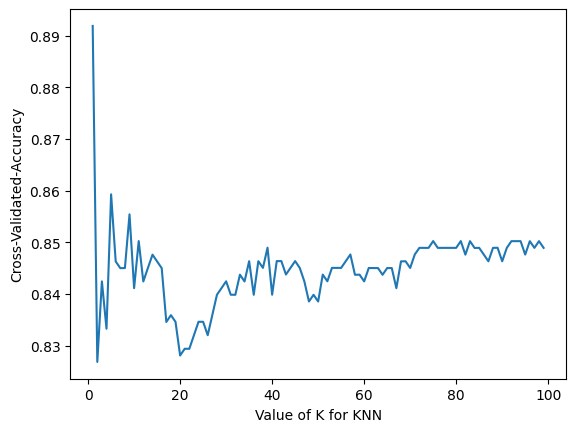

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.plot(k_range, k_scores)
plt.xlabel('Value of K for KNN')
plt.ylabel('Cross-Validated-Accuracy')

In [ ]:
scoring = {'accuracy' : make_scorer(accuracy_score),
           'precision' : make_scorer(precision_score),
           'recall' : make_scorer(recall_score),
           'f1_score' : make_scorer(f1_score)}

stratifyKF=StratifiedKFold(n_splits=30,random_state=42,shuffle=True)
KNN_score= cross_validate(modelKNN, X_train, y_train, cv=stratifyKF,scoring=scoring)
print(KNN_score)

print('accuracy',np.mean(KNN_score['test_accuracy']))
print('precision',np.mean(KNN_score['test_precision']))
print('recall',np.mean(KNN_score['test_recall']))
print('f1 score',np.mean(KNN_score['test_f1_score']))

{'fit_time': array([0.00212979, 0.00126839, 0.00113249, 0.00109172, 0.00114512,
       0.00113893, 0.00110936, 0.00116992, 0.00115037, 0.001086  ,
       0.00113058, 0.00145745, 0.00178361, 0.00111938, 0.00106692,
       0.00113869, 0.00110316, 0.00124526, 0.00111866, 0.00106955,
       0.00108504, 0.00109649, 0.00162244, 0.00178766, 0.0011251 ,
       0.0011096 , 0.00164723, 0.00121331, 0.00118375, 0.001122  ]), 'score_time': array([0.01272082, 0.00867391, 0.00849843, 0.00899267, 0.00859427,
       0.00848985, 0.0086503 , 0.00848389, 0.00859261, 0.00903416,
       0.00839853, 0.00870848, 0.01131368, 0.00835371, 0.00828099,
       0.00844336, 0.00877857, 0.00885653, 0.00924277, 0.00875831,
       0.00842834, 0.01104069, 0.01823044, 0.00961661, 0.0087595 ,
       0.00886154, 0.01029587, 0.00948477, 0.0085845 , 0.0087738 ]), 'test_accuracy': array([0.96153846, 0.88461538, 0.88461538, 0.96153846, 1.        ,
       0.96153846, 0.92307692, 1.        , 0.92307692, 0.88461538,
       0.96153

SVM

In [ ]:
from sklearn import svm
modelSVM_rbf = svm.SVC(kernel='rbf',gamma=0.1 , C=100,random_state=42,probability=True)  #Sigmoid kernel
#Train the model using the training sets
modelSVM_rbf.fit(X_train, y_train.ravel())

#Predict the response for train dataset
y_pred_train = modelSVM_rbf.predict(X_train)
#Predict the response for test dataset
y_pred = modelSVM_rbf.predict(X_test)
metric_calc(y_test,y_pred)
print_metric()



 Specificity or true negative rate : 0.9038461538461539
Confusion Matrix - Train:  
 [[416   0]
 [  0 352]]

 Accuracy - Train:  1.0
Accuracy - Test:  0.8860103626943006
confusion matrix - Test  : [[94 10]
 [12 77]]
mean absolute error  model:  0.11398963730569948

Classification report for test:
               precision    recall  f1-score   support

           0       0.89      0.90      0.90       104
           1       0.89      0.87      0.88        89

    accuracy                           0.89       193
   macro avg       0.89      0.88      0.89       193
weighted avg       0.89      0.89      0.89       193



In [ ]:
from sklearn.utils import shuffle
from sklearn import svm
# cross validation of SVM using Grid search CV

from sklearn.model_selection import GridSearchCV

# defining parameter range
param_grid = {'C': [0.1, 1, 10, 100],
              'gamma': [1, 0.1, 0.01, 0.001],
              'kernel': ['rbf','linear']
              }

grid = GridSearchCV(svm.SVC(random_state=42), param_grid, refit = True, verbose = 3)

# fitting the model for grid search
grid.fit(X_train, y_train)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.539 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.539 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.545 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.542 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.542 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.890 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.903 total time=   0.0s
[CV 3/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.851 total time=   0.0s
[CV 4/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.810 total time=   0.0s
[CV 5/5] END .....C=0.1, gamma=1, kernel=linear;, score=0.856 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.877 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf

GridSearchCV(estimator=SVC(random_state=42),
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': [1, 0.1, 0.01, 0.001],
                         'kernel': ['rbf', 'linear']},
             verbose=3)

In [ ]:
# print best parameter after tuning
print(grid.best_params_)

# print how our model looks after hyper-parameter tuning
print(grid.best_estimator_)

{'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}
SVC(C=100, gamma=0.1, random_state=42)


In [ ]:
scoring = {'accuracy' : make_scorer(accuracy_score),
           'precision' : make_scorer(precision_score),
           'recall' : make_scorer(recall_score),
           'f1_score' : make_scorer(f1_score)}

cv=KFold(n_splits=30,random_state=42,shuffle=True)
svm_score= cross_validate(modelSVM_rbf, X_train, y_train, cv=cv,scoring=scoring)
print(svm_score)

print('accuracy',np.mean(svm_score['test_accuracy']))
print('precision',np.mean(svm_score['test_precision']))
print('recall',np.mean(svm_score['test_recall']))
print('f1 score',np.mean(svm_score['test_f1_score']))

{'fit_time': array([0.13615537, 0.13667965, 0.15006089, 0.14981174, 0.15222192,
       0.17020082, 0.15361714, 0.15463781, 0.15407443, 0.15148425,
       0.15677667, 0.18180013, 0.14839411, 0.15277886, 0.15146351,
       0.15317369, 0.15604758, 0.08628774, 0.09981656, 0.08039212,
       0.07770467, 0.08100581, 0.08258796, 0.08066154, 0.0848248 ,
       0.08326101, 0.08150554, 0.08278704, 0.07993174, 0.09617305]), 'score_time': array([0.01321435, 0.01369882, 0.01565146, 0.0190835 , 0.01492476,
       0.01856709, 0.01450872, 0.01600242, 0.01383233, 0.01354337,
       0.01394105, 0.01570845, 0.01436663, 0.0146656 , 0.01415467,
       0.01424789, 0.01267743, 0.00854802, 0.00848913, 0.00839067,
       0.00893331, 0.00850773, 0.00851417, 0.00889182, 0.00853896,
       0.00962591, 0.0083952 , 0.00976133, 0.00844026, 0.00903654]), 'test_accuracy': array([0.88461538, 0.88461538, 0.73076923, 0.73076923, 0.92307692,
       0.88461538, 0.96153846, 0.92307692, 0.88461538, 0.76923077,
       0.92307

Ensembling

In [ ]:
from sklearn.ensemble import VotingClassifier



model_major = VotingClassifier(estimators=[('lr', modelLR), ('dt', modelDT),('knn', modelKNN),('RF',modelRF),('xgb', modelXGB),('EX', modelex),('svm', modelSVM_rbf)], voting='hard')
model_major.fit(X_train, y_train)
model_major.score(X_test,y_test)

0.9222797927461139

In [ ]:
scoring = {'accuracy' : make_scorer(accuracy_score),
           'precision' : make_scorer(precision_score),
           'recall' : make_scorer(recall_score),
           'f1_score' : make_scorer(f1_score)}

cv=KFold(n_splits=20,random_state=42,shuffle=True)
vote_score= cross_validate(model_major, X_train, y_train, cv=cv,scoring=scoring)
print(vote_score)

print('accuracy',np.mean(vote_score['test_accuracy']))
print('precision',np.mean(vote_score['test_precision']))
print('recall',np.mean(vote_score['test_recall']))
print('f1 score',np.mean(vote_score['test_f1_score']))

{'fit_time': array([0.80915809, 2.16914058, 0.46383429, 0.45400882, 0.45541072,
       0.44841909, 0.46393085, 0.44109869, 0.45801139, 0.44365478,
       0.46041679, 0.44761848, 0.46402836, 0.44937396, 0.4444325 ,
       0.45696282, 0.44122028, 0.46118951, 0.4375217 , 0.46229815]), 'score_time': array([0.06739116, 0.02629256, 0.02927423, 0.02686596, 0.02731276,
       0.02650976, 0.02688003, 0.02716327, 0.02692819, 0.02705121,
       0.02614808, 0.02847958, 0.02612662, 0.02646375, 0.03271508,
       0.02684903, 0.02669549, 0.02852893, 0.02631831, 0.02655268]), 'test_accuracy': array([0.94871795, 0.82051282, 0.84615385, 0.84615385, 0.8974359 ,
       0.94871795, 0.87179487, 0.8974359 , 0.92105263, 0.92105263,
       0.97368421, 0.94736842, 0.94736842, 0.97368421, 0.94736842,
       1.        , 0.89473684, 0.94736842, 0.89473684, 0.94736842]), 'test_precision': array([0.93333333, 1.        , 0.71428571, 0.88235294, 0.88888889,
       0.91666667, 0.8       , 0.89473684, 0.875     , 0.9473

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
modelada = AdaBoostClassifier(random_state=42,learning_rate=0.1, n_estimators=100)
modelada.fit(X_train, y_train)
modelada.score(X_test,y_test)

0.8238341968911918

In [ ]:
# creating a dic for the grid
grid = dict()

# estimator till 100
grid['n_estimators'] = [5, 10, 25, 50, 100]

# defining learning rate
grid['learning_rate'] = [0.0001, 0.01, 0.1, 1.0]

# defining the CV
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3)

# initializing the grid search
grid_search = GridSearchCV(estimator=modelada, param_grid=grid, n_jobs=-1, cv=cv, scoring='accuracy')


# training the model on grid search for hyperparameter tuning of Adaboost
grid_result = grid_search.fit(X_train, y_train)

# finding the best results /hyperparameter tuning of Adaboost
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))

Best: 0.858071 using {'learning_rate': 0.1, 'n_estimators': 50}


In [ ]:
scoring = {'accuracy' : make_scorer(accuracy_score),
           'precision' : make_scorer(precision_score),
           'recall' : make_scorer(recall_score),
           'f1_score' : make_scorer(f1_score)}

cv=KFold(n_splits=30,random_state=42,shuffle=True)
ada_score= cross_validate(modelada, X_train, y_train, cv=cv,scoring=scoring)
print(ada_score)

print('accuracy',np.mean(ada_score['test_accuracy']))
print('precision',np.mean(ada_score['test_precision']))
print('recall',np.mean(ada_score['test_recall']))
print('f1 score',np.mean(ada_score['test_f1_score']))

{'fit_time': array([0.38013864, 0.36474061, 0.36661553, 0.35945845, 0.35240197,
       0.36369181, 0.23746634, 0.23939681, 0.23307633, 0.22559834,
       0.22520113, 0.23583817, 0.2254138 , 0.24029589, 0.23581386,
       0.23838758, 0.23231769, 0.22143745, 0.23379087, 0.24070835,
       0.22998905, 0.22468376, 0.22223878, 0.23561311, 0.22691941,
       0.2253356 , 0.22462893, 0.23319221, 0.22263408, 0.22289562]), 'score_time': array([0.0416615 , 0.04087377, 0.04512715, 0.03880548, 0.03990912,
       0.03382945, 0.02347994, 0.02878046, 0.02251577, 0.02266169,
       0.02937484, 0.0224061 , 0.0311203 , 0.02250051, 0.02671194,
       0.02200484, 0.02976465, 0.02377963, 0.03212738, 0.03703237,
       0.02391362, 0.02664208, 0.02442908, 0.02304602, 0.02224612,
       0.03166032, 0.02348757, 0.02226138, 0.02196097, 0.02475882]), 'test_accuracy': array([0.84615385, 0.92307692, 0.76923077, 0.73076923, 0.88461538,
       0.88461538, 0.84615385, 0.80769231, 0.73076923, 0.80769231,
       0.76923

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn import tree
modelBag = BaggingClassifier(tree.DecisionTreeClassifier(random_state=42))
modelBag.fit(X_train, y_train)
modelBag.score(X_test,y_test)

0.8963730569948186

In [ ]:
scoring = {'accuracy' : make_scorer(accuracy_score),
           'precision' : make_scorer(precision_score),
           'recall' : make_scorer(recall_score),
           'f1_score' : make_scorer(f1_score)}

cv=KFold(n_splits=30,random_state=42,shuffle=True)
bag_score= cross_validate(modelBag, X_train, y_train, cv=cv,scoring=scoring)
print(bag_score)

print('accuracy',np.mean(bag_score['test_accuracy']))
print('precision',np.mean(bag_score['test_precision']))
print('recall',np.mean(bag_score['test_recall']))
print('f1 score',np.mean(bag_score['test_f1_score']))

{'fit_time': array([0.15366149, 0.05531359, 0.04167867, 0.03906608, 0.04254508,
       0.04724598, 0.0400598 , 0.04097152, 0.03972697, 0.04019547,
       0.03993583, 0.04519033, 0.03904581, 0.03852773, 0.03728485,
       0.04551578, 0.03796077, 0.03773522, 0.03688288, 0.04988766,
       0.03925037, 0.03715062, 0.03821445, 0.03673291, 0.04342532,
       0.0414052 , 0.04005575, 0.03976345, 0.03702331, 0.03793168]), 'score_time': array([0.01581645, 0.00929761, 0.0096035 , 0.00938106, 0.00937557,
       0.01362467, 0.00922203, 0.0096035 , 0.01015687, 0.00927687,
       0.01385045, 0.0112083 , 0.01003551, 0.00918913, 0.00960493,
       0.00911212, 0.00989366, 0.00931144, 0.00900531, 0.01032424,
       0.01050115, 0.00921369, 0.0092597 , 0.01021862, 0.01007771,
       0.01606917, 0.00930119, 0.01021838, 0.0095098 , 0.00921273]), 'test_accuracy': array([0.92307692, 0.96153846, 0.88461538, 0.80769231, 0.88461538,
       0.76923077, 0.96153846, 0.92307692, 0.80769231, 0.80769231,
       0.88461

In [ ]:
from sklearn.datasets import make_classification
from sklearn.ensemble import StackingClassifier

# get a stacking ensemble of models
def get_stacking():
  # define the base models
  level0 = list()
  level0.append(('lr', modelLR))
  level0.append(('xgb', modelXGB))
  level0.append(('rf', modelRF))
  level0.append(('knn',modelKNN))
  level0.append(('dt', modelDT))
  level0.append(('bagging', modelBag))
  level0.append(('svm', modelSVM_rbf))
  level0.append(('ada', modelada))
  level0.append(('EX', modelex))
  # define meta learner model
  level1 = RandomForestClassifier()
  # define the stacking ensemble
  modelst = StackingClassifier(estimators=level0, final_estimator=level1, cv=10)
  modelst.fit(X_train,y_train)
  y_pred_stack= modelst.predict(X_test)

  return modelst


def get_models():
  modelsdict = {'lr':modelLR,'xgb': modelXGB, 'rf': modelRF,'knn': modelKNN,'dt':modelDT,'bagging' : modelBag, 'svm' : modelSVM_rbf,'ada' : modelada, 'EX' :modelex, 'stacking' : get_stacking()}
  return modelsdict

In [ ]:
def evaluate_model(modelsdict):
  #scores = {'lr': LR, 'rf': RF,'knn': KNN,'dt' : DT, 'svm' : SVM, 'nb': NB}
  # scores = [LR, RF, KNN, DT, SVM,NB]
  cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=42)
  scores = cross_val_score(modelsdict,X_train, y_train, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')

  return scores


>lr 0.857 0.961 0.779 (0.039)
>xgb 0.911 0.961 0.831 (0.033)
>rf 0.924 0.961 0.831 (0.029)
>knn 0.928 0.974 0.870 (0.028)
>dt 0.877 0.935 0.818 (0.031)
>bagging 0.901 0.948 0.805 (0.031)
>svm 0.885 0.948 0.818 (0.034)
>ada 0.857 0.934 0.766 (0.040)
>EX 0.915 0.974 0.844 (0.034)
>stacking 0.923 0.961 0.831 (0.030)


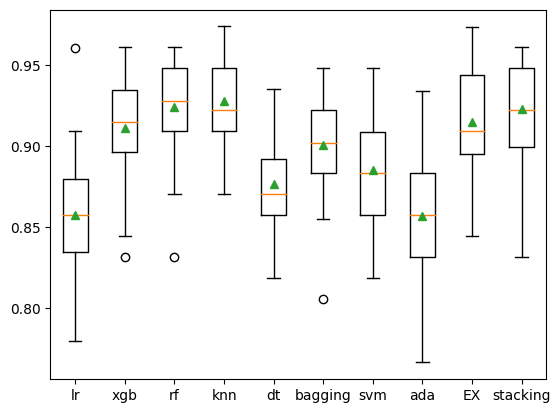

In [ ]:
from numpy import mean
from numpy import std
from matplotlib import pyplot
# get the models to evaluate
modelsdict = get_models()
# evaluate the models and store results
results, names = list(), list()
for name, modelsdict in modelsdict.items():
	scores = evaluate_model(modelsdict)
	results.append(scores)
	names.append(name)
	print('>%s %.3f %.3f %.3f (%.3f)' % (name, mean(scores), max(scores),min(scores),std(scores)))
# plot model performance for comparison
pyplot.boxplot(results, labels=names, showmeans=True)
pyplot.show()

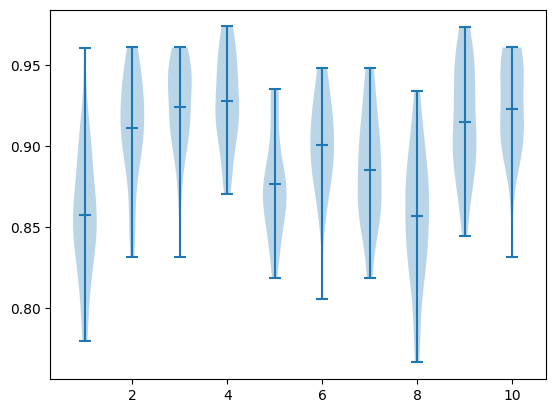

In [ ]:
pyplot.violinplot(results, showmeans=True)
pyplot.show()

In [ ]:
scoring = {'accuracy' : make_scorer(accuracy_score),
           'precision' : make_scorer(precision_score),
           'recall' : make_scorer(recall_score),
           'f1_score' : make_scorer(f1_score)}

cv=KFold(n_splits=50,random_state=42,shuffle=True)
stackscore= cross_validate(modelsdict, X_train, y_train, cv=cv,scoring=scoring)
print(stackscore)

print('accuracy',np.mean(stackscore['test_accuracy']))
print('max accuracy',np.max(stackscore['test_accuracy']))
print('precision',np.mean(stackscore['test_precision']))
print('recall',np.mean(stackscore['test_recall']))
print('f1 score',np.mean(stackscore['test_f1_score']))

{'fit_time': array([ 9.64179277,  9.59375238, 10.61435819,  8.19266438, 10.93692899,
       10.31017852,  8.57495093, 11.50031972,  9.03945422, 11.19385743,
       10.47180223,  8.85928273, 10.30458474, 10.7825613 ,  8.25938797,
       11.26699805,  9.64407372, 10.06376052, 10.60365534,  9.11840034,
       12.98107862, 10.4123466 ,  8.35904622, 11.06487131, 10.31533527,
        8.32734036, 10.93932533,  9.27068496, 10.52899981, 10.54088473,
        9.03086066,  9.72747159, 10.27634048,  8.88892126, 10.47546101,
       10.30910325,  9.05285501, 10.29676723, 10.38451385,  9.15754938,
        9.79770684, 10.37284493,  9.24793744,  9.56791878, 10.95478725,
       12.44764209,  8.46523595, 10.92511058, 10.13446283,  8.46634793]), 'score_time': array([0.06235933, 0.04576015, 0.04648995, 0.04763913, 0.0466454 ,
       0.06392384, 0.04860497, 0.04771638, 0.07604098, 0.04555893,
       0.04847693, 0.07807684, 0.05147338, 0.04718351, 0.0483861 ,
       0.04806519, 0.10016775, 0.04623556, 0.05364

In [ ]:
import shap

# Instead of passing the classifier object directly, pass its predict_proba method:
explainer = shap.Explainer(get_stacking().predict_proba, X_train)  # Assuming X_train is your training data

# Get SHAP values
shap_values = explainer.shap_values(X_test)

# ... (rest of your code)

PermutationExplainer explainer: 194it [05:23,  1.69s/it]


Shape of shap_values: (193, 19, 2)
Shape of X_test: (193, 19)


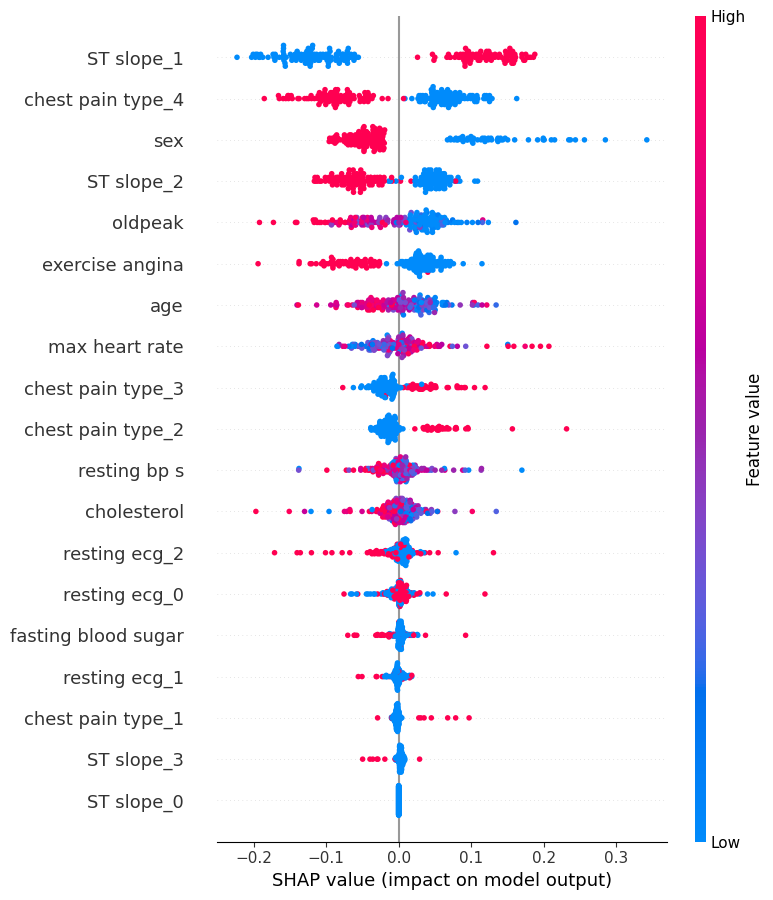

In [ ]:
# Check the shapes of SHAP values
print("Shape of shap_values:", shap_values.shape)
print("Shape of X_test:", X_test.shape)
feature_names = X.columns.tolist()
shap_values_class0 = shap_values[:, :, 0]  # SHAP values for class 0

# Create the summary plot for class 0
#shap.summary_plot(shap_values_class0, X_test)
shap.summary_plot(shap_values_class0, X_test,feature_names=feature_names)